# Analisis de resultados SHAP resumidos en texto (XGB y CAT)

Este cuaderno analiza conclusiones textuales de SHAP para modelos por asignatura.

Se generan:
- Conclusiones globales por modelo.
- Conclusiones por departamento (`DPTO Asignatura`) por modelo.
- Conclusiones por asignatura (`Descripcion_Materia`) por modelo.
- Analisis direccional por registro (`A favor` vs `En contra`) por modelo.
- Comparativo XGB vs CAT.
- Exportables CSV en `BASE_DIR/output`.

## 2. Configuracion (rutas, parametros, constantes)

In [68]:
import os
import re
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

# Rutas parametrizables
BASE_DIR = "Resultados_Modelo_v2"
FILENAME = "resultados_asig_xg_cat2026-02-23171813.csv"
INPUT_PATH = os.path.join(BASE_DIR, FILENAME)
OUTPUT_DIR = os.path.join(BASE_DIR, "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

PREREQ_XLSX = "Categoria preq_nopreq.xlsx"
PREREQ_XLSX_PATH = os.path.join(os.getcwd(), PREREQ_XLSX)

# Parametros de analisis
TOP_N_GLOBAL = 15
TOP_N_COURSE = 10
MIN_RECORDS_DEPT_DIRECTIONAL = 30

OBS_COL = "Observacion_Prerrequisito"
CATEGORY_COL = "Categoria_Prerrequisito"
CAT_HAS = "Prerrequisito cumplido"
CAT_NO = "No tiene pre requisito"
CATEGORY_ORDER = [CAT_HAS, CAT_NO]

## 3. Carga de datos + validacion de columnas

In [83]:
required_cols = {
    "DPTO Asignatura",
    "Descripcion_Materia",
    "interpretacion_general_xgb",
    "interpretacion_registro_xgb",
    "interpretacion_general_cat",
    "interpretacion_registro_cat",
}

if not os.path.exists(INPUT_PATH):
    raise FileNotFoundError(f"No se encontro el archivo: {INPUT_PATH}")

df = pd.read_csv(INPUT_PATH, sep=";")
missing = sorted(required_cols - set(df.columns))
if missing:
    raise ValueError(f"Faltan columnas requeridas: {missing}")

# Mantener filtro agregado por usuario
dpto_asig_ignorar = ["Bienestar Universitario", "Centro de Acompa?amiento Estud", "Deportes"]
df = df[df["DPTO Asignatura"].isin(dpto_asig_ignorar) == False]

# Ajuste de tipos requerido
# Transformar columnas Prereq* a float (normalizando coma decimal y vacios)
prereq_cols = [c for c in df.columns if str(c).startswith("Prereq")]
for col in prereq_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .replace("", np.nan)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)

for col in ["pga_inicial", "repitencia_prof_ref", "promedio_sem_t1","años_saber11_vs_clase","num_intentos_asignatura","num_semestres_profesor_asignatura"]:
    if col in df.columns:
        df[col]= df[col].astype(str).str.replace(",", ".").replace("", np.nan)
        df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)

for col in ["estrato","profesor_codigo"]:
    if col in df.columns:
        df[col] = df[col].astype("category")

#if "profesor_codigo" in df.columns:
#    df["profesor_codigo"] = df["profesor_codigo"].astype("category")

# Merge con catalogo de prerequisitos
if not os.path.exists(PREREQ_XLSX_PATH):
    raise FileNotFoundError(f"No se encontro el archivo de categorias: {PREREQ_XLSX_PATH}")

try:
    cat_df = pd.read_excel(PREREQ_XLSX_PATH)
except PermissionError as e:
    raise PermissionError(f"No se pudo leer {PREREQ_XLSX}. Cierra el archivo en Excel y vuelve a ejecutar. Detalle: {e}")
merge_cols = {"Descripcion_Materia", "Observacion_Prerrequisito"}
missing_merge_cols = sorted(merge_cols - set(cat_df.columns))
if missing_merge_cols:
    raise ValueError(f"Faltan columnas en {PREREQ_XLSX}: {missing_merge_cols}")

cat_df = cat_df[["Descripcion_Materia", "Observacion_Prerrequisito"]].drop_duplicates(subset=["Descripcion_Materia"])
df = df.merge(cat_df, on="Descripcion_Materia", how="left")
df[OBS_COL] = df[OBS_COL].fillna(CAT_NO)

# Estandarizar en 2 categorias exactas: Prerrequisito cumplido / No tiene pre requisito
obs_norm = (
    df[OBS_COL]
    .astype(str)
    .str.strip()
    .str.lower()
)

def map_categoria(v):
    if v == "prerrequisito cumplido":
        return CAT_HAS
    if v == "no tiene pre requisito":
        return CAT_NO

    # Fallback controlado para variantes de texto
    if "no tiene pre requisito" in v:
        return CAT_NO
    if "prerrequisito cumplido" in v:
        return CAT_HAS

    # Regla de seguridad para no perder filas sin match
    # (si no viene exactamente en catalogo, se marca como no tiene)
    return CAT_NO

df[CATEGORY_COL] = obs_norm.apply(map_categoria)
print(f"Filas: {len(df):,} | Columnas: {len(df.columns)}")
display(df[list(required_cols) + [OBS_COL, CATEGORY_COL]].head(3))
print("Conteo por categoria:")
display(df[CATEGORY_COL].value_counts(dropna=False).rename_axis(CATEGORY_COL).reset_index(name="n"))

C:\Users\00412\AppData\Local\Temp\ipykernel_23572\952160164.py:13: DtypeWarning: Columns (41,42,45,47,48,51,52,54,56,58,61,63,65,66,68,70,72,74,76,78,81,83,84,87,89,90,92,95,97,99,100,103,104,113,115,119,120,122,124,127,128,131,133,134,136,138,140,142,144,148,150,152,154,156,160,163,164,168,171,172,174,177,181,183,184,191,193,195,197,198,200,202,205,206,209,210,213,214,218,220,223,224,226,229,230,232,234,237,238,240,243,245,247) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_PATH, sep=";")


Filas: 20,700 | Columnas: 250


,Descripcion_Materia,interpretacion_general_xgb,interpretacion_registro_cat,interpretacion_registro_xgb,DPTO Asignatura,interpretacion_general_cat,Observacion_Prerrequisito,Categoria_Prerrequisito
0,EXIGENCIA DE FRANCES V,Variables con mayor impacto promedio (|SHAP|):...,A favor: Prereq_exigencia_de_frances_ii_Nota (...,A favor: Prereq_exigencia_de_frances_ii_Nota (...,Dpto. Lenguas Extranjeras,Variables con mayor impacto promedio (|SHAP|):...,Prerrequisito cumplido,Prerrequisito cumplido
1,EXIGENCIA DE FRANCES V,Variables con mayor impacto promedio (|SHAP|):...,"A favor: profesor_codigo (+0.067), sexo (+0.02...","A favor: programa (+0.091), procedencia_catego...",Dpto. Lenguas Extranjeras,Variables con mayor impacto promedio (|SHAP|):...,Prerrequisito cumplido,Prerrequisito cumplido
2,EXIGENCIA DE FRANCES V,Variables con mayor impacto promedio (|SHAP|):...,A favor: num_semestres_profesor_asignatura (+0...,A favor: num_semestres_profesor_asignatura (+0...,Dpto. Lenguas Extranjeras,Variables con mayor impacto promedio (|SHAP|):...,Prerrequisito cumplido,Prerrequisito cumplido


Conteo por categoria:


,Categoria_Prerrequisito,n
0,Prerrequisito cumplido,10363
1,No tiene pre requisito,10337


## 4. Helpers de parsing

Funciones requeridas:
- `parse_interpretacion_general(text) -> list[(var, weight)]`
- `parse_interpretacion_registro(text) -> dict con listas pos/neg`
- `normalize_variable_name(var)`
- `group_prereq(var)`

In [71]:
PAIR_PATTERN = re.compile(r"([^,|]+?)\s*\(\s*([+-]?\d+(?:\.\d+)?)\s*\)")

def normalize_variable_name(var):
    if var is None:
        return ""

    v = str(var)
    v = re.sub(r"\s+", " ", v).strip()

    # Limpieza de prefijos de texto que contaminan nombres de variable
    v = re.sub(r"^(?:A favor|En contra)\s*:\s*", "", v, flags=re.IGNORECASE)
    v = re.sub(r"^Variables con mayor impacto promedio\s*\(\|?SHAP\|?\)\s*:\s*", "", v, flags=re.IGNORECASE)
    v = re.sub(r"^[\)\]\[:;\-\s]+", "", v)

    # Si aparece prereq dentro de ruido, cortar desde prereq
    idx = v.lower().find("prereq")
    if idx > 0:
        left = v[:idx]
        if any(ch in left for ch in [":", ")", "("]):
            v = v[idx:]

    # Quitar basura inicial residual
    v = re.sub(r"^[^A-Za-z0-9_]+", "", v)
    return v.strip()

def group_prereq(var):
    v = normalize_variable_name(var)
    v_low = v.lower()

    # Agrupar toda variable de prerequisito sin mostrar nombre especifico
    if "prereq" in v_low:
        if v_low.endswith("_nota"):
            return "Prereq_Nota"
        if v_low.endswith("_intentos"):
            return "Prereq_Intentos"
        return "Prereq_Otros"

    return v

def _extract_pairs(text):
    if pd.isna(text):
        return []

    s = str(text).strip()
    if not s:
        return []

    pairs = []
    for var, num in PAIR_PATTERN.findall(s):
        v = normalize_variable_name(var)
        try:
            n = float(num)
        except Exception:
            continue
        if v:
            pairs.append((v, n))
    return pairs

def parse_interpretacion_general(text):
    # Espera magnitudes |SHAP|. Devuelve valor absoluto para robustez.
    out = []
    for var, val in _extract_pairs(text):
        out.append((var, abs(val)))
    return out

def parse_interpretacion_registro(text):
    # Esperado: "A favor: var (+0.1), ... | En contra: var (-0.2), ..."
    result = {"pos": [], "neg": []}
    if pd.isna(text):
        return result

    s = str(text).strip()
    if not s:
        return result

    parts = [p.strip() for p in s.split("|")]
    for part in parts:
        pl = part.lower()
        if "a favor" in pl:
            for var, val in _extract_pairs(part):
                result["pos"].append((var, abs(val)))
        elif "en contra" in pl:
            for var, val in _extract_pairs(part):
                result["neg"].append((var, -abs(val)))

    # Fallback si no se detectan etiquetas esperadas
    if not result["pos"] and not result["neg"]:
        for var, val in _extract_pairs(s):
            if val >= 0:
                result["pos"].append((var, val))
            else:
                result["neg"].append((var, val))

    return result

## 5. Dataset long para interpretacion_general (explosion de variables)

In [72]:
def build_general_long(df_in, model_tag, general_col):
    rows = []
    bad_idx = []

    for idx, row in df_in.iterrows():
        parsed = parse_interpretacion_general(row.get(general_col))
        if not parsed:
            bad_idx.append(idx)
            continue

        for var, weight in parsed:
            rows.append(
                {
                    "row_idx": idx,
                    "model": model_tag,
                    "depto": row.get("DPTO Asignatura"),
                    "asignatura": row.get("Descripcion_Materia"),
                    "categoria_prereq": row.get(CATEGORY_COL),
                    "variable": normalize_variable_name(var),
                    "variable_grouped": group_prereq(var),
                    "weight": float(weight),
                }
            )

    long_df = pd.DataFrame(rows)
    report = {
        "total_rows": len(df_in),
        "parsed_rows": len(df_in) - len(bad_idx),
        "not_parsed_rows": len(bad_idx),
        "not_parsed_examples": (
            df_in.loc[bad_idx, ["Descripcion_Materia", CATEGORY_COL, general_col]].head(5)
            if bad_idx
            else pd.DataFrame()
        ),
    }
    return long_df, report


def build_directional_long(df_in, model_tag, registro_col):
    rows = []
    bad_idx = []

    for idx, row in df_in.iterrows():
        parsed = parse_interpretacion_registro(row.get(registro_col))
        count_pairs = len(parsed["pos"]) + len(parsed["neg"])
        if count_pairs == 0:
            bad_idx.append(idx)
            continue

        for var, contrib in parsed["pos"]:
            rows.append(
                {
                    "row_idx": idx,
                    "model": model_tag,
                    "depto": row.get("DPTO Asignatura"),
                    "asignatura": row.get("Descripcion_Materia"),
                    "categoria_prereq": row.get(CATEGORY_COL),
                    "variable": normalize_variable_name(var),
                    "variable_grouped": group_prereq(var),
                    "direction": "pos",
                    "contrib_signed": float(contrib),
                }
            )

        for var, contrib in parsed["neg"]:
            rows.append(
                {
                    "row_idx": idx,
                    "model": model_tag,
                    "depto": row.get("DPTO Asignatura"),
                    "asignatura": row.get("Descripcion_Materia"),
                    "categoria_prereq": row.get(CATEGORY_COL),
                    "variable": normalize_variable_name(var),
                    "variable_grouped": group_prereq(var),
                    "direction": "neg",
                    "contrib_signed": float(contrib),
                }
            )

    long_df = pd.DataFrame(rows)
    report = {
        "total_rows": len(df_in),
        "parsed_rows": len(df_in) - len(bad_idx),
        "not_parsed_rows": len(bad_idx),
        "not_parsed_examples": (
            df_in.loc[bad_idx, ["Descripcion_Materia", CATEGORY_COL, registro_col]].head(5)
            if bad_idx
            else pd.DataFrame()
        ),
    }
    return long_df, report


def summarize_global(general_long, top_n=TOP_N_GLOBAL):
    if general_long.empty:
        return pd.DataFrame(), pd.DataFrame()

    agg = (
        general_long.groupby("variable_grouped", as_index=False)
        .agg(
            freq=("asignatura", "nunique"),
            mean_weight=("weight", "mean"),
            median_weight=("weight", "median"),
            total_weight=("weight", "sum"),
            n_rows=("weight", "size"),
        )
    )
    agg["score"] = agg["mean_weight"] * np.log1p(agg["freq"])
    agg = agg.sort_values(["score", "total_weight", "freq"], ascending=False).reset_index(drop=True)
    return agg.head(top_n), agg


def summarize_by_dept(general_long):
    if general_long.empty:
        return pd.DataFrame()

    agg = (
        general_long.groupby(["depto", "variable_grouped"], as_index=False)
        .agg(
            freq=("asignatura", "nunique"),
            mean_weight=("weight", "mean"),
            median_weight=("weight", "median"),
            total_weight=("weight", "sum"),
            n_rows=("weight", "size"),
        )
    )
    agg["score"] = agg["mean_weight"] * np.log1p(agg["freq"])
    return agg.sort_values(["depto", "score", "total_weight"], ascending=[True, False, False]).reset_index(drop=True)


def summarize_by_course(general_long, top_n=TOP_N_COURSE):
    if general_long.empty:
        return pd.DataFrame()

    tmp = general_long.sort_values(["asignatura", "weight"], ascending=[True, False]).copy()
    tmp["rank_in_course"] = tmp.groupby("asignatura")["weight"].rank(method="first", ascending=False)
    out = tmp[tmp["rank_in_course"] <= top_n].copy()
    return out.sort_values(["asignatura", "rank_in_course"]).reset_index(drop=True)


def summarize_directional(directional_long):
    if directional_long.empty:
        empty = pd.DataFrame()
        return empty, empty, empty

    summary = (
        directional_long.groupby("variable_grouped", as_index=False)
        .agg(
            total_count=("contrib_signed", "size"),
            pos_count=("direction", lambda s: int((s == "pos").sum())),
            neg_count=("direction", lambda s: int((s == "neg").sum())),
            mean_signed=("contrib_signed", "mean"),
            median_signed=("contrib_signed", "median"),
        )
    )

    pos_means = (
        directional_long[directional_long["direction"] == "pos"]
        .groupby("variable_grouped")["contrib_signed"]
        .mean()
        .rename("mean_pos")
    )
    neg_means = (
        directional_long[directional_long["direction"] == "neg"]
        .groupby("variable_grouped")["contrib_signed"]
        .mean()
        .rename("mean_neg")
    )

    summary = summary.merge(pos_means, on="variable_grouped", how="left")
    summary = summary.merge(neg_means, on="variable_grouped", how="left")

    summary["mean_pos"] = summary["mean_pos"].fillna(0.0)
    summary["mean_neg"] = summary["mean_neg"].fillna(0.0)
    summary["net_effect"] = summary["mean_signed"] * np.log1p(summary["total_count"])
    summary["net_rate"] = (summary["pos_count"] - summary["neg_count"]) / summary["total_count"].clip(lower=1)

    pos = summary.sort_values("net_effect", ascending=False).reset_index(drop=True)
    neg = summary.sort_values("net_effect", ascending=True).reset_index(drop=True)
    return summary, pos, neg


def summarize_directional_by_dept(directional_long, min_records=MIN_RECORDS_DEPT_DIRECTIONAL):
    if directional_long.empty:
        return pd.DataFrame()

    dept_sizes = directional_long.groupby("depto").size().rename("n_records").reset_index()
    eligible = set(dept_sizes.loc[dept_sizes["n_records"] >= min_records, "depto"])
    if not eligible:
        return pd.DataFrame()

    tmp = directional_long[directional_long["depto"].isin(eligible)].copy()

    out = (
        tmp.groupby(["depto", "variable_grouped"], as_index=False)
        .agg(
            total_count=("contrib_signed", "size"),
            pos_count=("direction", lambda s: int((s == "pos").sum())),
            neg_count=("direction", lambda s: int((s == "neg").sum())),
            mean_signed=("contrib_signed", "mean"),
        )
    )

    out["net_effect"] = out["mean_signed"] * np.log1p(out["total_count"])
    out["net_rate"] = (out["pos_count"] - out["neg_count"]) / out["total_count"].clip(lower=1)
    return out.sort_values(["depto", "net_effect"], ascending=[True, False]).reset_index(drop=True)


def plot_top_bar(summary_df, value_col, label_col, title, top_n=15):
    if summary_df.empty:
        print("Sin datos para graficar.")
        return

    plot_df = summary_df.head(top_n).copy().iloc[::-1]
    plt.figure(figsize=(10, 6))
    if HAS_SEABORN:
        sns.barplot(data=plot_df, x=value_col, y=label_col, hue=label_col, legend=False, palette="viridis")
    else:
        plt.barh(plot_df[label_col], plot_df[value_col])
    plt.title(title)
    plt.xlabel(value_col)
    plt.ylabel(label_col)
    plt.tight_layout()
    plt.show()


def plot_dept_heatmap(dept_summary, top_vars=12, top_depts=15, title="Heatmap depto vs variable"):
    if dept_summary.empty:
        print("Sin datos para heatmap.")
        return

    top_var_names = (
        dept_summary.groupby("variable_grouped")["score"]
        .mean()
        .sort_values(ascending=False)
        .head(top_vars)
        .index
    )
    top_depto_names = (
        dept_summary.groupby("depto")["score"]
        .mean()
        .sort_values(ascending=False)
        .head(top_depts)
        .index
    )

    sub = dept_summary[
        dept_summary["variable_grouped"].isin(top_var_names)
        & dept_summary["depto"].isin(top_depto_names)
    ]

    if sub.empty:
        print("Heatmap omitido: datos insuficientes.")
        return

    pivot = sub.pivot_table(index="depto", columns="variable_grouped", values="score", aggfunc="mean", fill_value=0)

    plt.figure(figsize=(1.1 * max(8, len(pivot.columns)), 0.6 * max(6, len(pivot.index))))
    if HAS_SEABORN:
        sns.heatmap(pivot, cmap="YlGnBu")
    else:
        plt.imshow(pivot.values, aspect="auto")
        plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
        plt.yticks(range(len(pivot.index)), pivot.index)
        plt.colorbar(label="score")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def build_bullets_global(df_top, model_name):
    if df_top.empty:
        return f"### {model_name}\n- Sin datos suficientes para resumen global."

    lines = [f"### {model_name}"]
    for _, r in df_top.head(5).iterrows():
        lines.append(
            f"- **{r['variable_grouped']}**: score={r['score']:.4f}, freq={int(r['freq'])}, mean={r['mean_weight']:.4f}."
        )
    return "\n".join(lines)


def build_bullets_dept(dept_summary, model_name, top_k=3):
    if dept_summary.empty:
        return f"### {model_name}\n- Sin datos por departamento."

    lines = [f"### {model_name} - Resumen por departamento"]
    for depto, g in dept_summary.groupby("depto"):
        top = g.sort_values("score", ascending=False).head(top_k)
        pieces = [f"{row.variable_grouped} (score={row.score:.3f})" for row in top.itertuples()]
        lines.append(f"- **{depto}**: " + ", ".join(pieces))
    return "\n".join(lines)


def run_model_segmented(df_in, model_label, general_col, registro_col):
    results = {}

    for cat_value in CATEGORY_ORDER:
        seg = df_in[df_in[CATEGORY_COL] == cat_value].copy()

        general_long, report_general = build_general_long(seg, model_label, general_col)
        directional_long, report_dir = build_directional_long(seg, model_label, registro_col)

        global_top, global_full = summarize_global(general_long, top_n=TOP_N_GLOBAL)
        dept = summarize_by_dept(general_long)
        course = summarize_by_course(general_long, top_n=TOP_N_COURSE)
        directional, directional_pos, directional_neg = summarize_directional(directional_long)
        directional_dept = summarize_directional_by_dept(directional_long, MIN_RECORDS_DEPT_DIRECTIONAL)

        results[cat_value] = {
            "n_rows": len(seg),
            "general_long": general_long,
            "report_general": report_general,
            "global_top": global_top,
            "global_full": global_full,
            "dept": dept,
            "course": course,
            "directional": directional,
            "directional_pos": directional_pos,
            "directional_neg": directional_neg,
            "directional_dept": directional_dept,
            "report_dir": report_dir,
        }

    return results


def add_category_column(dct, key):
    parts = []
    for cat_value in CATEGORY_ORDER:
        df_part = dct.get(cat_value, {}).get(key)
        if isinstance(df_part, pd.DataFrame) and not df_part.empty:
            part = df_part.copy()
            part["categoria_prereq"] = cat_value
            parts.append(part)
    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, ignore_index=True)


def display_segmented_results(results, model_name):
    for cat_value in CATEGORY_ORDER:
        r = results[cat_value]
        display(Markdown(f"## {model_name} - {cat_value}"))
        print(f"Filas del segmento: {r['n_rows']}")

        n_asig_unicas = r["general_long"]["asignatura"].nunique() if not r["general_long"].empty else 0
        print(
            "Reporte de parsing (general):",
            {
                **{k: v for k, v in r["report_general"].items() if k != "not_parsed_examples"},
                "asignaturas_unicas": int(n_asig_unicas),
            },
        )
        if r["report_general"]["not_parsed_rows"] > 0:
            display(Markdown("**Ejemplos no parseados (general):**"))
            display(r["report_general"]["not_parsed_examples"])

        display(Markdown("### Global"))
        display(r["global_top"])
        display(Markdown(build_bullets_global(r["global_top"], model_name)))
        plot_top_bar(r["global_top"], "score", "variable_grouped", f"{model_name} - {cat_value} - Top global por score", top_n=TOP_N_GLOBAL)

        display(Markdown("### Por departamento"))
        display(r["dept"].head(30))
        display(Markdown(build_bullets_dept(r["dept"], model_name, top_k=5)))
        plot_dept_heatmap(r["dept"], title=f"{model_name} - {cat_value} - Heatmap depto vs variable")

        display(Markdown("### Por asignatura"))
        display(r["course"].head(40))

        display(Markdown("### Direccional por registro"))
        print("Reporte de parsing (direccional):", {k: v for k, v in r["report_dir"].items() if k != "not_parsed_examples"})
        if r["report_dir"]["not_parsed_rows"] > 0:
            display(Markdown("**Ejemplos no parseados (direccional):**"))
            display(r["report_dir"]["not_parsed_examples"])

        directional_pos_only = r["directional_pos"][r["directional_pos"]["net_effect"] > 0].copy()
        directional_neg_only = r["directional_neg"][r["directional_neg"]["net_effect"] < 0].copy()

        display(Markdown("#### Top efecto neto positivo (solo net_effect > 0)"))
        display(directional_pos_only.head(20))
        display(Markdown("#### Top efecto neto negativo (solo net_effect < 0)"))
        display(directional_neg_only.head(20))

        plot_top_bar(
            directional_pos_only,
            value_col="net_effect",
            label_col="variable_grouped",
            title=f"{model_name} - {cat_value} - Top efecto neto positivo (net_effect > 0)",
            top_n=15,
        )

        plot_top_bar(
            directional_neg_only.assign(net_effect_abs=lambda d: d["net_effect"].abs()) if not directional_neg_only.empty else directional_neg_only,
            value_col="net_effect_abs" if not directional_neg_only.empty else "net_effect",
            label_col="variable_grouped",
            title=f"{model_name} - {cat_value} - Top efecto neto negativo (|net_effect|, net_effect < 0)",
            top_n=15,
        )

        if not r["directional_dept"].empty:
            display(Markdown("#### Direccional por departamento"))
            display(r["directional_dept"].head(40))
        else:
            print("Direccional por departamento omitido por volumen insuficiente.")

## 6. Conclusiones globales (XGB) + outputs (tablas + texto)

## XGBoost - Prerrequisito cumplido

Filas del segmento: 10363
Reporte de parsing (general): {'total_rows': 10363, 'parsed_rows': 10363, 'not_parsed_rows': 0, 'asignaturas_unicas': 95}


### Global

,variable_grouped,freq,mean_weight,median_weight,total_weight,n_rows,score
0,pga_inicial,95,0.139398,0.119,1444.579,10363,0.636260
1,profesor_codigo,90,0.131093,0.120,1312.637,10013,0.591343
2,promedio_sem_t1,95,0.119406,0.109,1237.408,10363,0.545012
3,programa,41,0.082921,0.074,545.124,6574,0.309932
4,num_semestres_profesor_asignatura,74,0.057086,0.040,474.100,8305,0.246469
5,Prereq_Nota,95,0.045513,0.031,1000.237,21977,0.207737
6,asistencia_cree_t1,86,0.035903,0.033,343.268,9561,0.160339
7,repitencia_prof_ref,65,0.033954,0.025,254.009,7481,0.142255
8,edad_curso,56,0.027522,0.026,178.124,6472,0.111274
9,num_intentos_asignatura,19,0.033534,0.031,60.328,1799,0.100459


### XGBoost
- **pga_inicial**: score=0.6363, freq=95, mean=0.1394.
- **profesor_codigo**: score=0.5913, freq=90, mean=0.1311.
- **promedio_sem_t1**: score=0.5450, freq=95, mean=0.1194.
- **programa**: score=0.3099, freq=41, mean=0.0829.
- **num_semestres_profesor_asignatura**: score=0.2465, freq=74, mean=0.0571.

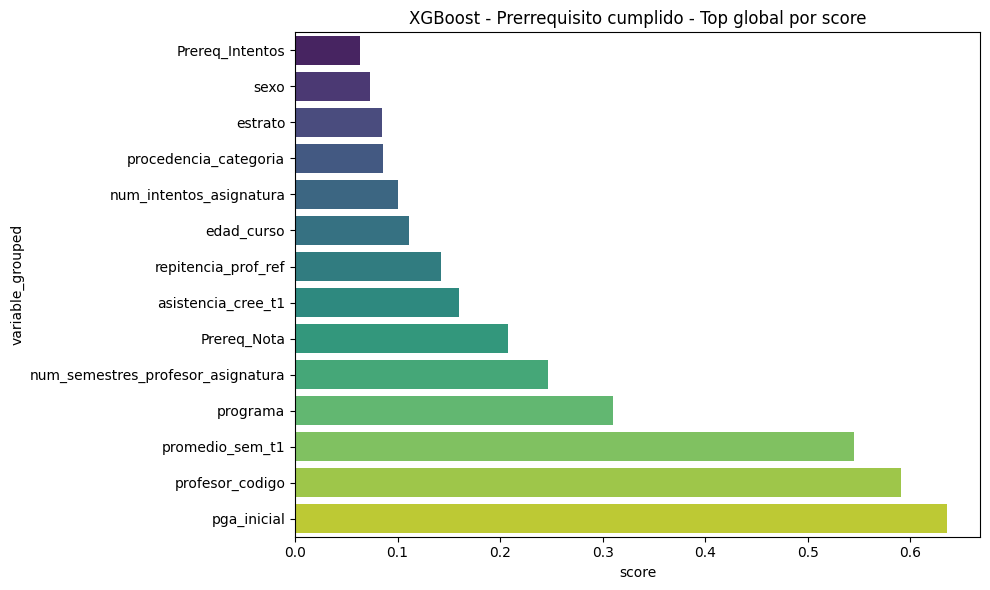

### Por departamento

,depto,variable_grouped,freq,mean_weight,median_weight,total_weight,n_rows,score
0,Dpto. Arquitectura y Urbanismo,promedio_sem_t1,1,0.202000,0.202,10.706,53,0.140016
1,Dpto. Arquitectura y Urbanismo,pga_inicial,1,0.169000,0.169,8.957,53,0.117142
2,Dpto. Arquitectura y Urbanismo,Prereq_Nota,1,0.156000,0.156,8.268,53,0.108131
3,Dpto. Arquitectura y Urbanismo,profesor_codigo,1,0.104000,0.104,5.512,53,0.072087
4,Dpto. Arquitectura y Urbanismo,asistencia_cree_t1,1,0.052000,0.052,2.756,53,0.036044
5,Dpto. Arquitectura y Urbanismo,num_semestres_profesor_asignatura,1,0.039000,0.039,2.067,53,0.027033
6,Dpto. Arquitectura y Urbanismo,sexo,1,0.039000,0.039,2.067,53,0.027033
7,Dpto. Arquitectura y Urbanismo,estrato,1,0.038000,0.038,2.014,53,0.026340
8,Dpto. Arquitectura y Urbanismo,edad_curso,1,0.034000,0.034,1.802,53,0.023567
9,Dpto. Arquitectura y Urbanismo,procedencia_categoria,1,0.029000,0.029,1.537,53,0.020101


### XGBoost - Resumen por departamento
- **Dpto. Arquitectura y Urbanismo**: promedio_sem_t1 (score=0.140), pga_inicial (score=0.117), Prereq_Nota (score=0.108), profesor_codigo (score=0.072), asistencia_cree_t1 (score=0.036)
- **Dpto. Comunicación Social**: profesor_codigo (score=0.418), pga_inicial (score=0.269), promedio_sem_t1 (score=0.192), Prereq_Nota (score=0.070), edad_curso (score=0.056)
- **Dpto. Cs Politica y Rel Intern**: profesor_codigo (score=0.168), pga_inicial (score=0.089), num_semestres_profesor_asignatura (score=0.078), promedio_sem_t1 (score=0.067), asistencia_cree_t1 (score=0.022)
- **Dpto. Derecho**: pga_inicial (score=0.548), promedio_sem_t1 (score=0.327), profesor_codigo (score=0.300), num_semestres_profesor_asignatura (score=0.243), asistencia_cree_t1 (score=0.139)
- **Dpto. Emprendim y Management**: pga_inicial (score=0.186), profesor_codigo (score=0.156), num_semestres_profesor_asignatura (score=0.138), promedio_sem_t1 (score=0.130), asistencia_cree_t1 (score=0.063)
- **Dpto. Español**: promedio_sem_t1 (score=0.116), programa (score=0.112), profesor_codigo (score=0.105), pga_inicial (score=0.067), num_semestres_profesor_asignatura (score=0.028)
- **Dpto. Finanzas y Contaduría**: pga_inicial (score=0.195), promedio_sem_t1 (score=0.148), profesor_codigo (score=0.096), asistencia_cree_t1 (score=0.064), programa (score=0.059)
- **Dpto. Física**: promedio_sem_t1 (score=0.217), pga_inicial (score=0.196), profesor_codigo (score=0.145), programa (score=0.088), num_semestres_profesor_asignatura (score=0.078)
- **Dpto. Ing. Civil y Ambiental**: pga_inicial (score=0.329), promedio_sem_t1 (score=0.203), profesor_codigo (score=0.197), Prereq_Nota (score=0.095), asistencia_cree_t1 (score=0.072)
- **Dpto. Ingeniería Industrial**: pga_inicial (score=0.580), profesor_codigo (score=0.203), promedio_sem_t1 (score=0.185), programa (score=0.101), repitencia_prof_ref (score=0.098)
- **Dpto. Ingeniería Mecánica**: promedio_sem_t1 (score=0.270), pga_inicial (score=0.255), profesor_codigo (score=0.127), Prereq_Nota (score=0.076), asistencia_cree_t1 (score=0.048)
- **Dpto. Ingeniería de Sistemas**: pga_inicial (score=0.351), profesor_codigo (score=0.335), promedio_sem_t1 (score=0.282), repitencia_prof_ref (score=0.108), Prereq_Nota (score=0.096)
- **Dpto. Lenguas Extranjeras**: profesor_codigo (score=0.553), Prereq_Nota (score=0.285), pga_inicial (score=0.259), programa (score=0.244), promedio_sem_t1 (score=0.185)
- **Dpto. Matematicas y estadístic**: promedio_sem_t1 (score=0.368), pga_inicial (score=0.353), profesor_codigo (score=0.253), programa (score=0.172), num_semestres_profesor_asignatura (score=0.158)
- **Dpto. Medicina**: promedio_sem_t1 (score=0.221), profesor_codigo (score=0.217), pga_inicial (score=0.145), Prereq_Nota (score=0.075), asistencia_cree_t1 (score=0.025)
- **Dpto. Mercadeo y Neg. Internac**: pga_inicial (score=0.172), promedio_sem_t1 (score=0.127), num_semestres_profesor_asignatura (score=0.086), repitencia_prof_ref (score=0.045), asistencia_cree_t1 (score=0.043)
- **Dpto. Psicología**: pga_inicial (score=0.064), promedio_sem_t1 (score=0.028), asistencia_cree_t1 (score=0.024), num_semestres_profesor_asignatura (score=0.023), estrato (score=0.016)
- **Dpto. Salud Pública**: pga_inicial (score=0.052), promedio_sem_t1 (score=0.027), profesor_codigo (score=0.024), Prereq_Nota (score=0.015), num_semestres_profesor_asignatura (score=0.010)
- **Dpto. de Economía**: profesor_codigo (score=0.179), pga_inicial (score=0.147), promedio_sem_t1 (score=0.088), programa (score=0.045), num_semestres_profesor_asignatura (score=0.039)

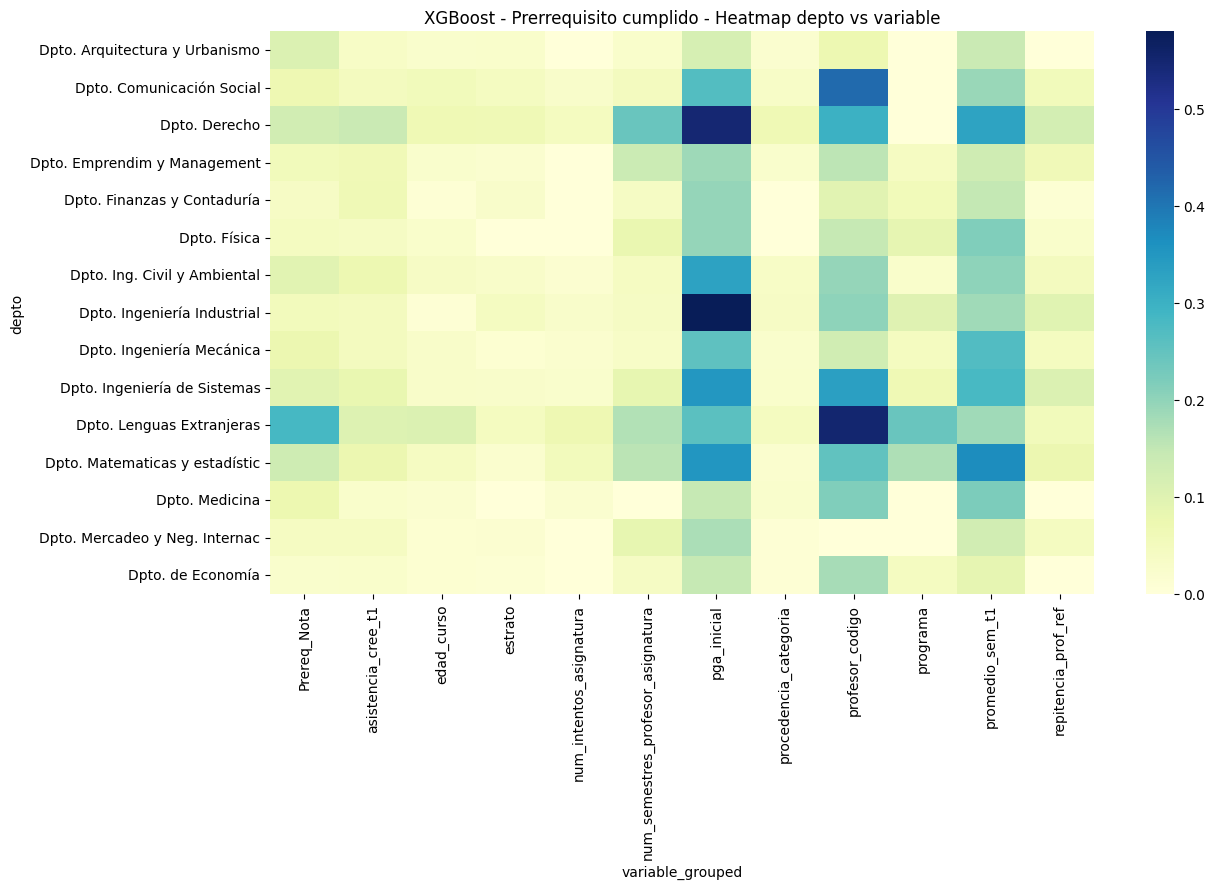

### Por asignatura

,row_idx,model,depto,asignatura,categoria_prereq,variable,variable_grouped,weight,rank_in_course
0,12358,XGBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,profesor_codigo,profesor_codigo,0.217,1.0
1,12359,XGBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,profesor_codigo,profesor_codigo,0.217,2.0
2,12360,XGBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,profesor_codigo,profesor_codigo,0.217,3.0
3,12361,XGBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,profesor_codigo,profesor_codigo,0.217,4.0
4,12362,XGBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,profesor_codigo,profesor_codigo,0.217,5.0
5,12363,XGBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,profesor_codigo,profesor_codigo,0.217,6.0
6,12364,XGBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,profesor_codigo,profesor_codigo,0.217,7.0
7,12365,XGBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,profesor_codigo,profesor_codigo,0.217,8.0
8,12366,XGBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,profesor_codigo,profesor_codigo,0.217,9.0
9,12367,XGBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,profesor_codigo,profesor_codigo,0.217,10.0


### Direccional por registro

Reporte de parsing (direccional): {'total_rows': 10363, 'parsed_rows': 10363, 'not_parsed_rows': 0}


#### Top efecto neto positivo (solo net_effect > 0)

,variable_grouped,total_count,pos_count,neg_count,mean_signed,median_signed,mean_pos,mean_neg,net_effect,net_rate
0,programa,7552,5200,2352,0.039488,0.019,0.081589,-0.053591,0.352620,0.377119
1,asistencia_cree_t1,10079,5736,4343,0.003955,0.006,0.034097,-0.035856,0.036454,0.138208
2,edad_curso,9707,5685,4022,0.000870,0.004,0.020196,-0.026447,0.007988,0.171320
3,procedencia_categoria,9675,5066,4609,0.000292,0.001,0.014598,-0.015432,0.002679,0.047235
4,sexo,9622,5009,4613,0.000206,0.001,0.012710,-0.013371,0.001889,0.041156


#### Top efecto neto negativo (solo net_effect < 0)

,variable_grouped,total_count,pos_count,neg_count,mean_signed,median_signed,mean_pos,mean_neg,net_effect,net_rate
0,pga_inicial,10295,4233,6062,-0.037136,-0.032,0.125592,-0.150766,-0.343114,-0.177659
1,num_semestres_profesor_asignatura,9120,3835,5285,-0.015062,-0.009,0.045608,-0.059086,-0.137340,-0.158991
2,Prereq_Nota,28355,12463,15892,-0.011358,-0.005,0.030360,-0.044074,-0.116445,-0.120931
3,promedio_sem_t1,10313,4815,5498,-0.009932,-0.010,0.117840,-0.121831,-0.091784,-0.066227
4,repitencia_prof_ref,9024,4328,4696,-0.002486,-0.002,0.029599,-0.032057,-0.022645,-0.040780
5,num_intentos_asignatura,8712,5256,3456,-0.002104,0.001,0.008909,-0.018853,-0.019088,0.206612
6,Prereq_Intentos,14257,9739,4518,-0.001299,0.001,0.003594,-0.011847,-0.012428,0.366206
7,estrato,9784,4781,5003,-0.000837,-0.001,0.016761,-0.017654,-0.007690,-0.022690
8,profesor_codigo,10136,4921,5215,-0.000798,-0.004,0.132647,-0.126719,-0.007359,-0.029006


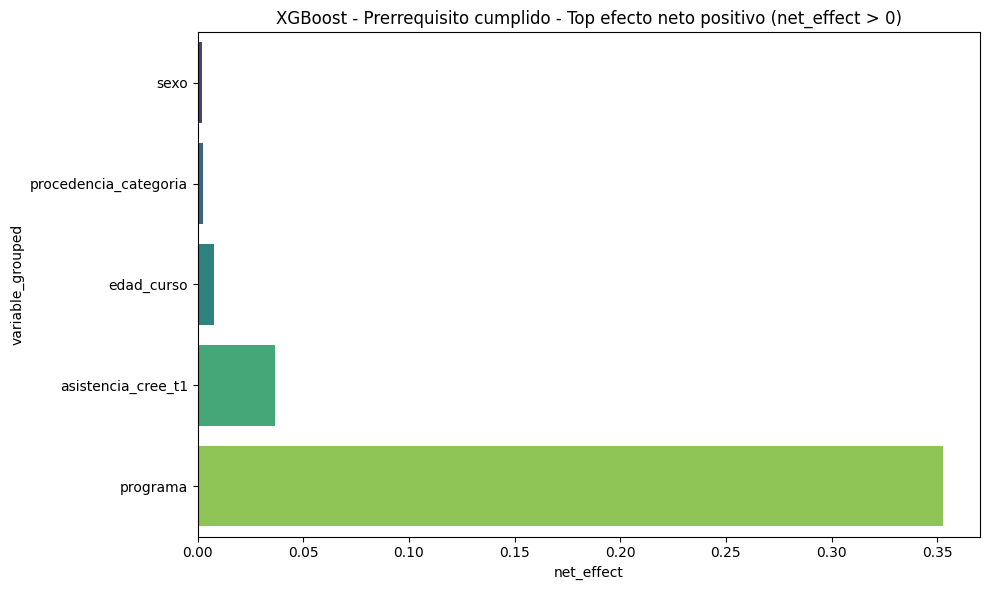

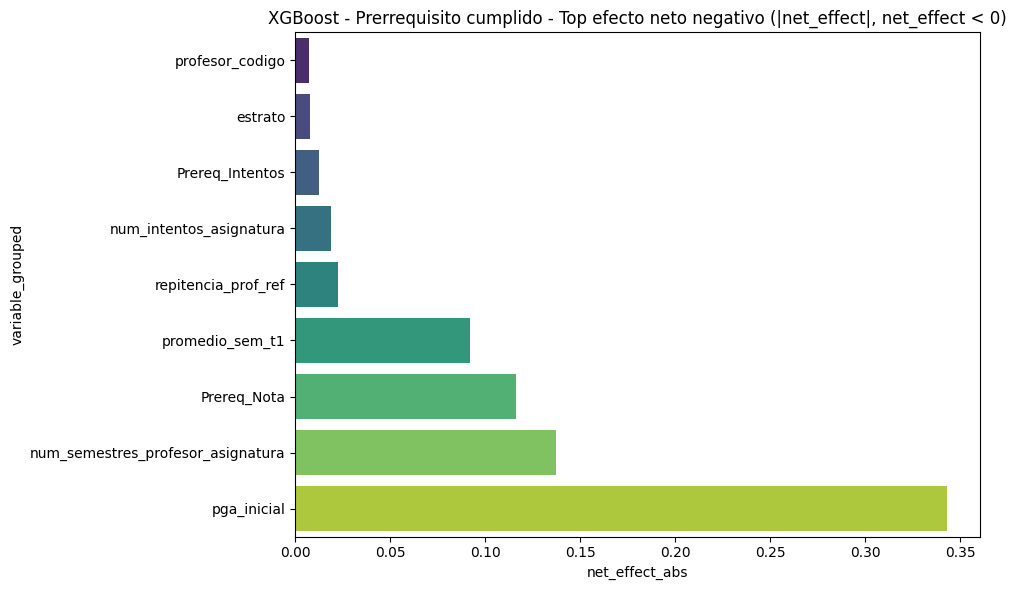

#### Direccional por departamento

,depto,variable_grouped,total_count,pos_count,neg_count,mean_signed,net_effect,net_rate
0,Dpto. Arquitectura y Urbanismo,profesor_codigo,53,34,19,0.066981,0.267187,0.283019
1,Dpto. Arquitectura y Urbanismo,sexo,52,37,15,0.006846,0.027181,0.423077
2,Dpto. Arquitectura y Urbanismo,edad_curso,52,30,22,0.006346,0.025196,0.153846
3,Dpto. Arquitectura y Urbanismo,num_intentos_asignatura,53,48,5,0.005434,0.021676,0.811321
4,Dpto. Arquitectura y Urbanismo,procedencia_categoria,53,30,23,0.003566,0.014225,0.132075
5,Dpto. Arquitectura y Urbanismo,Prereq_Intentos,45,43,2,0.000378,0.001446,0.911111
6,Dpto. Arquitectura y Urbanismo,estrato,53,27,26,-0.001792,-0.007150,0.018868
7,Dpto. Arquitectura y Urbanismo,repitencia_prof_ref,52,28,24,-0.002192,-0.008704,0.076923
8,Dpto. Arquitectura y Urbanismo,pga_inicial,53,30,23,-0.004019,-0.016031,0.132075
9,Dpto. Arquitectura y Urbanismo,asistencia_cree_t1,53,28,25,-0.005189,-0.020698,0.056604


## XGBoost - No tiene pre requisito

Filas del segmento: 10337
Reporte de parsing (general): {'total_rows': 10337, 'parsed_rows': 10337, 'not_parsed_rows': 0, 'asignaturas_unicas': 88}


### Global

,variable_grouped,freq,mean_weight,median_weight,total_weight,n_rows,score
0,profesor_codigo,80,0.154251,0.133,1505.181,9758,0.677848
1,pga_inicial,60,0.127394,0.111,974.948,7653,0.523702
2,puntaje_saber11,28,0.118727,0.065,318.664,2684,0.399790
3,promedio_sem_t1,44,0.095283,0.080,509.571,5348,0.362708
4,saber11_matematicas,41,0.079906,0.063,372.842,4666,0.298663
5,programa,41,0.072676,0.062,496.380,6830,0.271640
6,saber11_Ciencias_Naturales,38,0.064400,0.054,295.080,4582,0.235933
7,num_semestres_profesor_asignatura,70,0.050147,0.038,401.478,8006,0.213761
8,saber11_ingles,35,0.049700,0.028,161.922,3258,0.178100
9,asistencia_cree_t1,59,0.043281,0.043,346.857,8014,0.177209


### XGBoost
- **profesor_codigo**: score=0.6778, freq=80, mean=0.1543.
- **pga_inicial**: score=0.5237, freq=60, mean=0.1274.
- **puntaje_saber11**: score=0.3998, freq=28, mean=0.1187.
- **promedio_sem_t1**: score=0.3627, freq=44, mean=0.0953.
- **saber11_matematicas**: score=0.2987, freq=41, mean=0.0799.

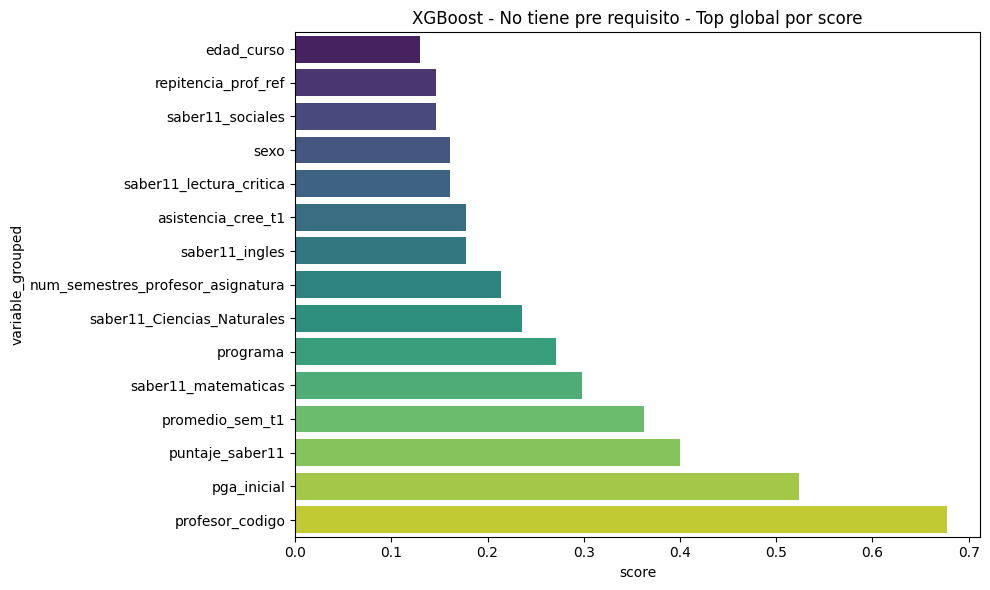

### Por departamento

,depto,variable_grouped,freq,mean_weight,median_weight,total_weight,n_rows,score
0,Centro de Acompañamiento Estud,profesor_codigo,7,0.171487,0.178,73.225,427,0.356597
1,Centro de Acompañamiento Estud,num_semestres_profesor_asignatura,5,0.148929,0.054,37.679,253,0.266845
2,Centro de Acompañamiento Estud,programa,1,0.338000,0.338,27.040,80,0.234284
3,Centro de Acompañamiento Estud,pga_inicial,1,0.257000,0.257,20.560,80,0.178139
4,Centro de Acompañamiento Estud,sexo,5,0.074431,0.059,20.915,281,0.133362
5,Centro de Acompañamiento Estud,saber11_Ciencias_Naturales,7,0.058563,0.033,24.655,421,0.121778
6,Centro de Acompañamiento Estud,saber11_matematicas,8,0.051094,0.043,23.912,468,0.112265
7,Centro de Acompañamiento Estud,Tipo_colegio,9,0.047082,0.046,25.801,548,0.108411
8,Centro de Acompañamiento Estud,promedio_sem_t1,1,0.153000,0.153,12.240,80,0.106052
9,Centro de Acompañamiento Estud,estrato,5,0.058293,0.057,16.905,290,0.104447


### XGBoost - Resumen por departamento
- **Centro de Acompañamiento Estud**: profesor_codigo (score=0.357), num_semestres_profesor_asignatura (score=0.267), programa (score=0.234), pga_inicial (score=0.178), sexo (score=0.133)
- **Dpto. Comunicación Social**: profesor_codigo (score=0.171), pga_inicial (score=0.149), promedio_sem_t1 (score=0.075), num_semestres_profesor_asignatura (score=0.050), saber11_lectura_critica (score=0.048)
- **Dpto. Derecho**: profesor_codigo (score=0.514), puntaje_saber11 (score=0.402), promedio_sem_t1 (score=0.369), pga_inicial (score=0.352), repitencia_prof_ref (score=0.151)
- **Dpto. Educación**: profesor_codigo (score=0.196), pga_inicial (score=0.085), programa (score=0.063), promedio_sem_t1 (score=0.035), asistencia_cree_t1 (score=0.030)
- **Dpto. Emprendim y Management**: promedio_sem_t1 (score=0.156), pga_inicial (score=0.078), num_semestres_profesor_asignatura (score=0.076), profesor_codigo (score=0.072), sexo (score=0.056)
- **Dpto. Español**: profesor_codigo (score=0.233), pga_inicial (score=0.096), sexo (score=0.090), promedio_sem_t1 (score=0.080), puntaje_saber11 (score=0.065)
- **Dpto. Finanzas y Contaduría**: profesor_codigo (score=0.299), pga_inicial (score=0.090), saber11_Ciencias_Naturales (score=0.050), saber11_matematicas (score=0.044), sexo (score=0.039)
- **Dpto. Historia y Cs. Sociales**: profesor_codigo (score=0.343), pga_inicial (score=0.260), programa (score=0.218), promedio_sem_t1 (score=0.208), saber11_sociales (score=0.132)
- **Dpto. Humanidades y Filosofía**: profesor_codigo (score=0.387), pga_inicial (score=0.220), programa (score=0.202), promedio_sem_t1 (score=0.129), num_semestres_profesor_asignatura (score=0.073)
- **Dpto. Ing. Civil y Ambiental**: puntaje_saber11 (score=0.340), profesor_codigo (score=0.278), num_semestres_profesor_asignatura (score=0.130), saber11_Ciencias_Naturales (score=0.095), pga_inicial (score=0.080)
- **Dpto. Ingeniería Industrial**: profesor_codigo (score=0.320), pga_inicial (score=0.221), promedio_sem_t1 (score=0.108), programa (score=0.082), num_semestres_profesor_asignatura (score=0.069)
- **Dpto. Ingeniería Mecánica**: pga_inicial (score=0.175), profesor_codigo (score=0.113), promedio_sem_t1 (score=0.084), asistencia_cree_t1 (score=0.028), edad_curso (score=0.021)
- **Dpto. Ingeniería de Sistemas**: saber11_matematicas (score=0.262), pga_inicial (score=0.233), saber11_ingles (score=0.203), saber11_Ciencias_Naturales (score=0.188), saber11_lectura_critica (score=0.141)
- **Dpto. Lenguas Extranjeras**: puntaje_saber11 (score=0.313), profesor_codigo (score=0.209), edad_curso (score=0.194), pga_inicial (score=0.145), saber11_matematicas (score=0.115)
- **Dpto. Matematicas y estadístic**: profesor_codigo (score=0.235), pga_inicial (score=0.224), puntaje_saber11 (score=0.204), saber11_matematicas (score=0.196), saber11_Ciencias_Naturales (score=0.150)
- **Dpto. Mercadeo y Neg. Internac**: num_semestres_profesor_asignatura (score=0.111), puntaje_saber11 (score=0.076), pga_inicial (score=0.069), promedio_sem_t1 (score=0.058), saber11_Ciencias_Naturales (score=0.056)
- **Dpto. Psicología**: profesor_codigo (score=0.245), promedio_sem_t1 (score=0.120), pga_inicial (score=0.093), asistencia_cree_t1 (score=0.065), num_semestres_profesor_asignatura (score=0.059)
- **Dpto. Química y Biología**: profesor_codigo (score=0.255), pga_inicial (score=0.185), puntaje_saber11 (score=0.128), promedio_sem_t1 (score=0.119), programa (score=0.093)
- **Dpto. Salud Pública**: profesor_codigo (score=0.100), pga_inicial (score=0.064), num_semestres_profesor_asignatura (score=0.046), puntaje_saber11 (score=0.032), repitencia_prof_ref (score=0.030)
- **Dpto. de Economía**: pga_inicial (score=0.145), profesor_codigo (score=0.113), asistencia_cree_t1 (score=0.039), saber11_matematicas (score=0.030), programa (score=0.028)
- **Dpto.Ing Eléctrica-Electrónica**: programa (score=0.091), promedio_sem_t1 (score=0.079), pga_inicial (score=0.064), num_semestres_profesor_asignatura (score=0.059), edad_curso (score=0.048)

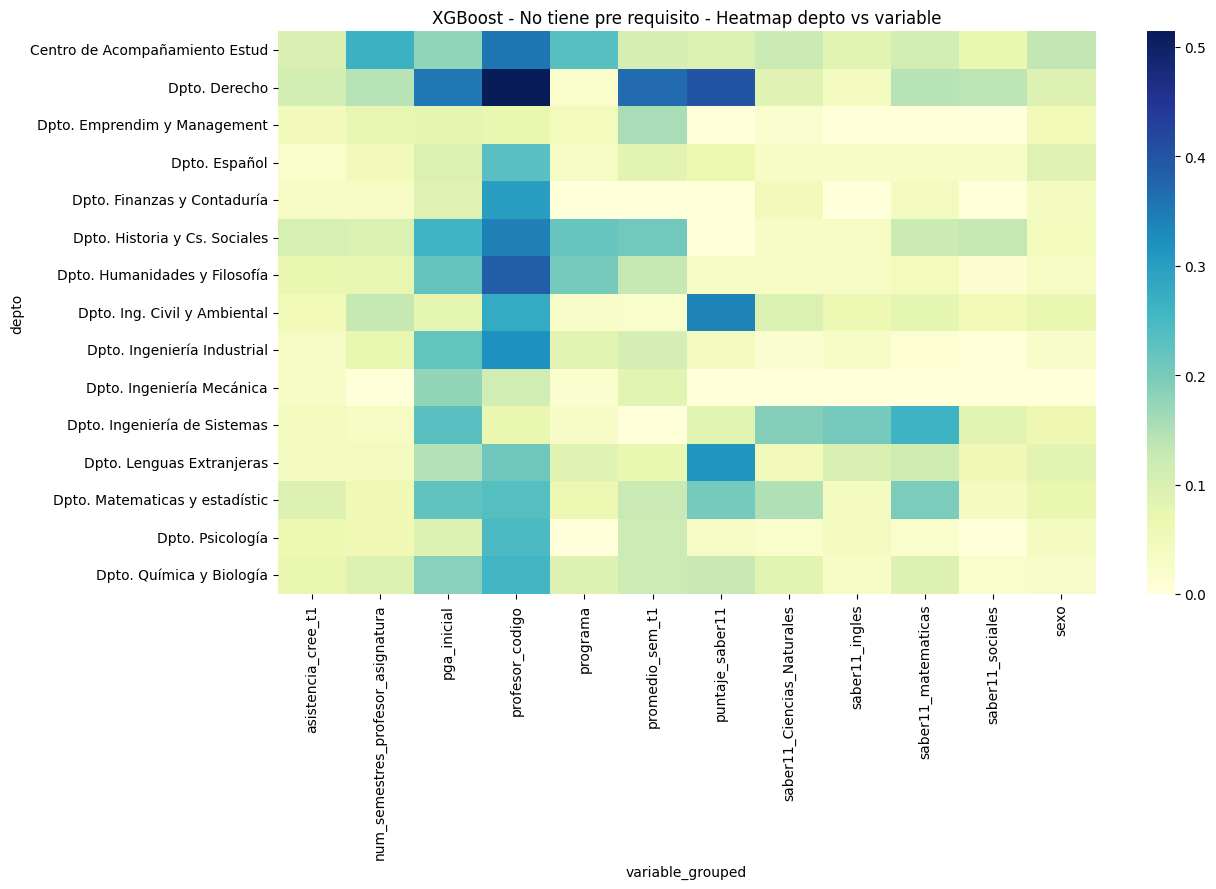

### Por asignatura

,row_idx,model,depto,asignatura,categoria_prereq,variable,variable_grouped,weight,rank_in_course
0,7439,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,1.0
1,7440,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,2.0
2,7441,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,3.0
3,7442,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,4.0
4,7443,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,5.0
5,7444,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,6.0
6,7445,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,7.0
7,7446,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,8.0
8,7447,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,9.0
9,7448,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,10.0


### Direccional por registro

Reporte de parsing (direccional): {'total_rows': 10337, 'parsed_rows': 10337, 'not_parsed_rows': 0}


#### Top efecto neto positivo (solo net_effect > 0)

,variable_grouped,total_count,pos_count,neg_count,mean_signed,median_signed,mean_pos,mean_neg,net_effect,net_rate
0,Tipo_colegio,9769,4839,4930,0.006809,-0.000,0.027454,-0.013455,0.062558,-0.009315
1,procedencia_categoria,9624,5589,4035,0.002261,0.003,0.015466,-0.016029,0.020741,0.161471
2,programa,8855,4745,4110,0.001069,0.000,0.055090,-0.061299,0.009717,0.071711


#### Top efecto neto negativo (solo net_effect < 0)

,variable_grouped,total_count,pos_count,neg_count,mean_signed,median_signed,mean_pos,mean_neg,net_effect,net_rate
0,puntaje_saber11,2645,890,1755,-0.081197,-0.039,0.058274,-0.151926,-0.639900,-0.327032
1,profesor_codigo,10180,4378,5802,-0.031253,-0.022,0.136516,-0.157845,-0.288407,-0.139882
2,saber11_matematicas,4865,2220,2645,-0.025605,-0.007,0.057243,-0.095140,-0.217385,-0.087359
3,saber11_Ciencias_Naturales,4844,2336,2508,-0.017006,-0.003,0.047275,-0.076878,-0.144306,-0.035508
4,saber11_sociales,4712,1939,2773,-0.014740,-0.007,0.025963,-0.043202,-0.124676,-0.176995
5,num_semestres_profesor_asignatura,10107,4802,5305,-0.012782,-0.002,0.031920,-0.053246,-0.117866,-0.049767
6,saber11_ingles,4712,2419,2293,-0.013898,0.002,0.027041,-0.057087,-0.117553,0.026740
7,saber11_lectura_critica,4644,2168,2476,-0.012860,-0.003,0.021870,-0.043271,-0.108588,-0.066322
8,pga_inicial,7621,3491,4130,-0.008054,-0.016,0.130869,-0.125482,-0.071989,-0.083847
9,promedio_sem_t1,5340,2754,2586,-0.007225,0.003,0.085526,-0.106002,-0.062014,0.031461


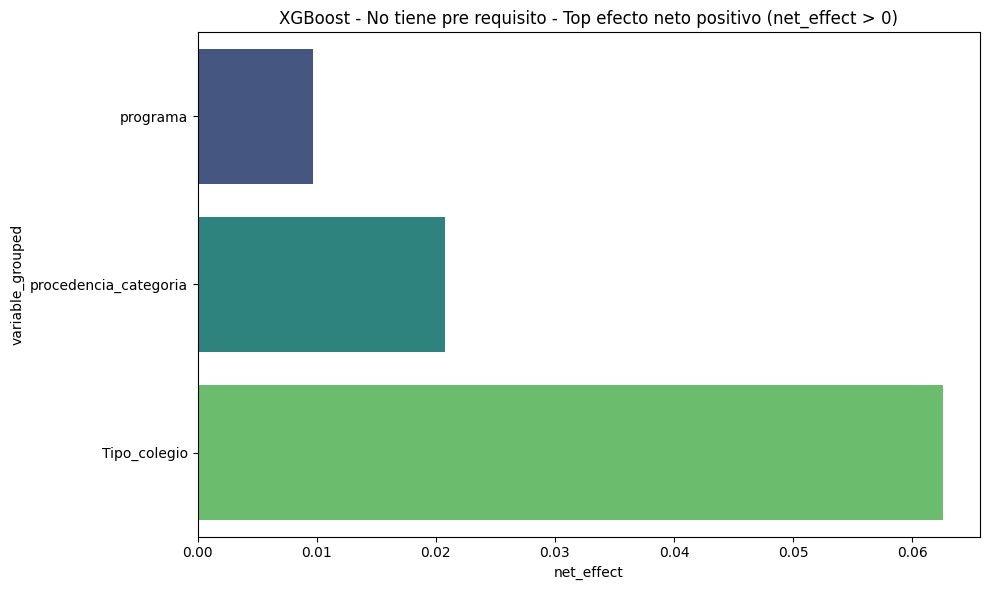

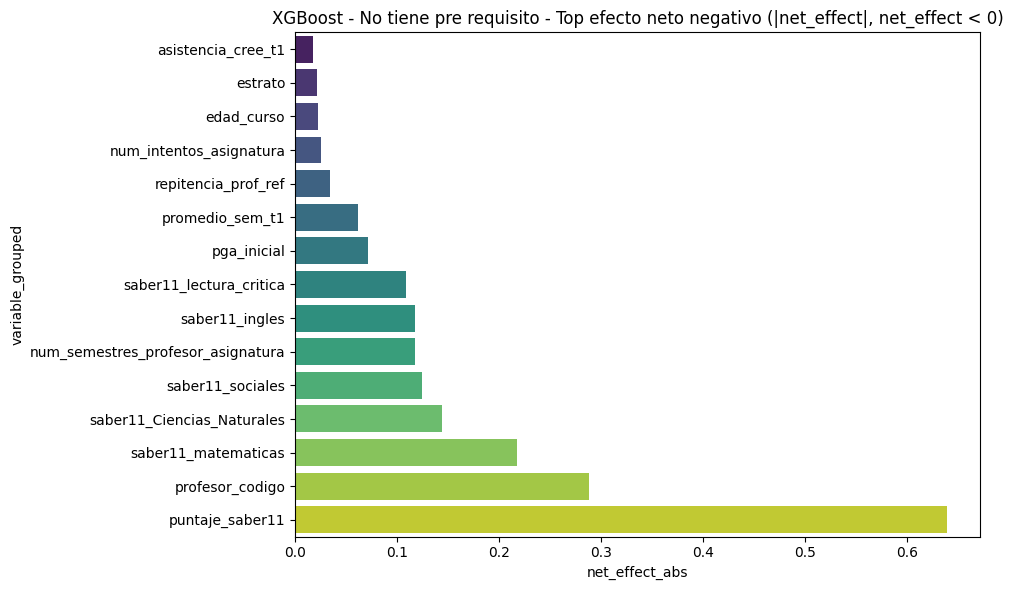

#### Direccional por departamento

,depto,variable_grouped,total_count,pos_count,neg_count,mean_signed,net_effect,net_rate
0,Centro de Acompañamiento Estud,Tipo_colegio,537,342,195,0.020240,0.127268,0.273743
1,Centro de Acompañamiento Estud,asistencia_cree_t1,345,256,89,0.003591,0.020996,0.484058
2,Centro de Acompañamiento Estud,saber11_ingles,460,261,199,0.001848,0.011333,0.134783
3,Centro de Acompañamiento Estud,num_intentos_asignatura,196,113,83,0.000628,0.003315,0.153061
4,Centro de Acompañamiento Estud,saber11_lectura_critica,462,271,191,0.000050,0.000306,0.173160
5,Centro de Acompañamiento Estud,saber11_matematicas,461,252,209,-0.000826,-0.005071,0.093275
6,Centro de Acompañamiento Estud,Tipo_calendario,469,233,236,-0.001038,-0.006389,-0.006397
7,Centro de Acompañamiento Estud,procedencia_categoria,524,284,240,-0.002431,-0.015228,0.083969
8,Centro de Acompañamiento Estud,edad_curso,533,318,215,-0.005169,-0.032462,0.193246
9,Centro de Acompañamiento Estud,sexo,525,228,297,-0.005196,-0.032556,-0.131429


Resumen XGB listo por categorias.


In [73]:
# XGB segmentado por categoria de prerequisito
results_xgb = run_model_segmented(df, "XGBoost", "interpretacion_general_xgb", "interpretacion_registro_xgb")
display_segmented_results(results_xgb, "XGBoost")

# Dataframes de salida consolidados (incluyen categoria_prereq)
global_summary_xgb = add_category_column(results_xgb, "global_top")
global_summary_xgb_full = add_category_column(results_xgb, "global_full")
dept_summary_xgb = add_category_column(results_xgb, "dept")
course_summary_xgb = add_category_column(results_xgb, "course")
directional_summary_xgb = add_category_column(results_xgb, "directional")
directional_summary_xgb_pos = add_category_column(results_xgb, "directional_pos")
directional_summary_xgb_neg = add_category_column(results_xgb, "directional_neg")
directional_dept_summary_xgb = add_category_column(results_xgb, "directional_dept")

print("Resumen XGB listo por categorias.")

## 7. Conclusiones por departamento (XGB)

In [74]:
display(Markdown("## XGB - Tablas por categoria (sin mezcla)"))
for cat_value in CATEGORY_ORDER:
    display(Markdown(f"### {cat_value} - global_summary_xgb"))
    display(global_summary_xgb[global_summary_xgb["categoria_prereq"] == cat_value].head(40))

    display(Markdown(f"### {cat_value} - dept_summary_xgb"))
    display(dept_summary_xgb[dept_summary_xgb["categoria_prereq"] == cat_value].head(40))

    display(Markdown(f"### {cat_value} - course_summary_xgb"))
    display(course_summary_xgb[course_summary_xgb["categoria_prereq"] == cat_value].head(40))

## XGB - Tablas por categoria (sin mezcla)

### Prerrequisito cumplido - global_summary_xgb

,variable_grouped,freq,mean_weight,median_weight,total_weight,n_rows,score,categoria_prereq
0,pga_inicial,95,0.139398,0.119,1444.579,10363,0.636260,Prerrequisito cumplido
1,profesor_codigo,90,0.131093,0.120,1312.637,10013,0.591343,Prerrequisito cumplido
2,promedio_sem_t1,95,0.119406,0.109,1237.408,10363,0.545012,Prerrequisito cumplido
3,programa,41,0.082921,0.074,545.124,6574,0.309932,Prerrequisito cumplido
4,num_semestres_profesor_asignatura,74,0.057086,0.040,474.100,8305,0.246469,Prerrequisito cumplido
5,Prereq_Nota,95,0.045513,0.031,1000.237,21977,0.207737,Prerrequisito cumplido
6,asistencia_cree_t1,86,0.035903,0.033,343.268,9561,0.160339,Prerrequisito cumplido
7,repitencia_prof_ref,65,0.033954,0.025,254.009,7481,0.142255,Prerrequisito cumplido
8,edad_curso,56,0.027522,0.026,178.124,6472,0.111274,Prerrequisito cumplido
9,num_intentos_asignatura,19,0.033534,0.031,60.328,1799,0.100459,Prerrequisito cumplido


### Prerrequisito cumplido - dept_summary_xgb

,depto,variable_grouped,freq,mean_weight,median_weight,total_weight,n_rows,score,categoria_prereq
0,Dpto. Arquitectura y Urbanismo,promedio_sem_t1,1,0.202000,0.202,10.706,53,0.140016,Prerrequisito cumplido
1,Dpto. Arquitectura y Urbanismo,pga_inicial,1,0.169000,0.169,8.957,53,0.117142,Prerrequisito cumplido
2,Dpto. Arquitectura y Urbanismo,Prereq_Nota,1,0.156000,0.156,8.268,53,0.108131,Prerrequisito cumplido
3,Dpto. Arquitectura y Urbanismo,profesor_codigo,1,0.104000,0.104,5.512,53,0.072087,Prerrequisito cumplido
4,Dpto. Arquitectura y Urbanismo,asistencia_cree_t1,1,0.052000,0.052,2.756,53,0.036044,Prerrequisito cumplido
5,Dpto. Arquitectura y Urbanismo,num_semestres_profesor_asignatura,1,0.039000,0.039,2.067,53,0.027033,Prerrequisito cumplido
6,Dpto. Arquitectura y Urbanismo,sexo,1,0.039000,0.039,2.067,53,0.027033,Prerrequisito cumplido
7,Dpto. Arquitectura y Urbanismo,estrato,1,0.038000,0.038,2.014,53,0.026340,Prerrequisito cumplido
8,Dpto. Arquitectura y Urbanismo,edad_curso,1,0.034000,0.034,1.802,53,0.023567,Prerrequisito cumplido
9,Dpto. Arquitectura y Urbanismo,procedencia_categoria,1,0.029000,0.029,1.537,53,0.020101,Prerrequisito cumplido


...

,variable_grouped,freq,mean_weight,median_weight,total_weight,n_rows,score,categoria_prereq
14,profesor_codigo,80,0.154251,0.133,1505.181,9758,0.677848,No tiene pre requisito
15,pga_inicial,60,0.127394,0.111,974.948,7653,0.523702,No tiene pre requisito
16,puntaje_saber11,28,0.118727,0.065,318.664,2684,0.399790,No tiene pre requisito
17,promedio_sem_t1,44,0.095283,0.080,509.571,5348,0.362708,No tiene pre requisito
18,saber11_matematicas,41,0.079906,0.063,372.842,4666,0.298663,No tiene pre requisito
19,programa,41,0.072676,0.062,496.380,6830,0.271640,No tiene pre requisito
20,saber11_Ciencias_Naturales,38,0.064400,0.054,295.080,4582,0.235933,No tiene pre requisito
21,num_semestres_profesor_asignatura,70,0.050147,0.038,401.478,8006,0.213761,No tiene pre requisito
22,saber11_ingles,35,0.049700,0.028,161.922,3258,0.178100,No tiene pre requisito
23,asistencia_cree_t1,59,0.043281,0.043,346.857,8014,0.177209,No tiene pre requisito


### No tiene pre requisito - dept_summary_xgb

,depto,variable_grouped,freq,mean_weight,median_weight,total_weight,n_rows,score,categoria_prereq
212,Centro de Acompañamiento Estud,profesor_codigo,7,0.171487,0.178,73.225,427,0.356597,No tiene pre requisito
213,Centro de Acompañamiento Estud,num_semestres_profesor_asignatura,5,0.148929,0.054,37.679,253,0.266845,No tiene pre requisito
214,Centro de Acompañamiento Estud,programa,1,0.338000,0.338,27.040,80,0.234284,No tiene pre requisito
215,Centro de Acompañamiento Estud,pga_inicial,1,0.257000,0.257,20.560,80,0.178139,No tiene pre requisito
216,Centro de Acompañamiento Estud,sexo,5,0.074431,0.059,20.915,281,0.133362,No tiene pre requisito
217,Centro de Acompañamiento Estud,saber11_Ciencias_Naturales,7,0.058563,0.033,24.655,421,0.121778,No tiene pre requisito
218,Centro de Acompañamiento Estud,saber11_matematicas,8,0.051094,0.043,23.912,468,0.112265,No tiene pre requisito
219,Centro de Acompañamiento Estud,Tipo_colegio,9,0.047082,0.046,25.801,548,0.108411,No tiene pre requisito
220,Centro de Acompañamiento Estud,promedio_sem_t1,1,0.153000,0.153,12.240,80,0.106052,No tiene pre requisito
221,Centro de Acompañamiento Estud,estrato,5,0.058293,0.057,16.905,290,0.104447,No tiene pre requisito


### No tiene pre requisito - course_summary_xgb

,row_idx,model,depto,asignatura,categoria_prereq,variable,variable_grouped,weight,rank_in_course
950,7439,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,1.0
951,7440,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,2.0
952,7441,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,3.0
953,7442,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,4.0
954,7443,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,5.0
955,7444,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,6.0
956,7445,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,7.0
957,7446,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,8.0
958,7447,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,9.0
959,7448,XGBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,profesor_codigo,profesor_codigo,0.121,10.0


## 8. Conclusiones por asignatura (XGB)

In [75]:
display(Markdown("## XGB - Direccional por categoria (sin mezcla)"))
for cat_value in CATEGORY_ORDER:
    display(Markdown(f"### {cat_value} - directional_summary_xgb_pos"))
    display(directional_summary_xgb_pos[directional_summary_xgb_pos["categoria_prereq"] == cat_value].head(40))

    display(Markdown(f"### {cat_value} - directional_summary_xgb_neg"))
    display(directional_summary_xgb_neg[directional_summary_xgb_neg["categoria_prereq"] == cat_value].head(40))

## XGB - Direccional por categoria (sin mezcla)

### Prerrequisito cumplido - directional_summary_xgb_pos

,variable_grouped,total_count,pos_count,neg_count,mean_signed,median_signed,mean_pos,mean_neg,net_effect,net_rate,categoria_prereq
0,programa,7552,5200,2352,0.039488,0.019,0.081589,-0.053591,0.352620,0.377119,Prerrequisito cumplido
1,asistencia_cree_t1,10079,5736,4343,0.003955,0.006,0.034097,-0.035856,0.036454,0.138208,Prerrequisito cumplido
2,edad_curso,9707,5685,4022,0.000870,0.004,0.020196,-0.026447,0.007988,0.171320,Prerrequisito cumplido
3,procedencia_categoria,9675,5066,4609,0.000292,0.001,0.014598,-0.015432,0.002679,0.047235,Prerrequisito cumplido
4,sexo,9622,5009,4613,0.000206,0.001,0.012710,-0.013371,0.001889,0.041156,Prerrequisito cumplido
5,profesor_codigo,10136,4921,5215,-0.000798,-0.004,0.132647,-0.126719,-0.007359,-0.029006,Prerrequisito cumplido
6,estrato,9784,4781,5003,-0.000837,-0.001,0.016761,-0.017654,-0.007690,-0.022690,Prerrequisito cumplido
7,Prereq_Intentos,14257,9739,4518,-0.001299,0.001,0.003594,-0.011847,-0.012428,0.366206,Prerrequisito cumplido
8,num_intentos_asignatura,8712,5256,3456,-0.002104,0.001,0.008909,-0.018853,-0.019088,0.206612,Prerrequisito cumplido
9,repitencia_prof_ref,9024,4328,4696,-0.002486,-0.002,0.029599,-0.032057,-0.022645,-0.040780,Prerrequisito cumplido


### Prerrequisito cumplido - directional_summary_xgb_neg

,variable_grouped,total_count,pos_count,neg_count,mean_signed,median_signed,mean_pos,mean_neg,net_effect,net_rate,categoria_prereq
0,pga_inicial,10295,4233,6062,-0.037136,-0.032,0.125592,-0.150766,-0.343114,-0.177659,Prerrequisito cumplido
1,num_semestres_profesor_asignatura,9120,3835,5285,-0.015062,-0.009,0.045608,-0.059086,-0.137340,-0.158991,Prerrequisito cumplido
2,Prereq_Nota,28355,12463,15892,-0.011358,-0.005,0.030360,-0.044074,-0.116445,-0.120931,Prerrequisito cumplido
3,promedio_sem_t1,10313,4815,5498,-0.009932,-0.010,0.117840,-0.121831,-0.091784,-0.066227,Prerrequisito cumplido
4,repitencia_prof_ref,9024,4328,4696,-0.002486,-0.002,0.029599,-0.032057,-0.022645,-0.040780,Prerrequisito cumplido
5,num_intentos_asignatura,8712,5256,3456,-0.002104,0.001,0.008909,-0.018853,-0.019088,0.206612,Prerrequisito cumplido
6,Prereq_Intentos,14257,9739,4518,-0.001299,0.001,0.003594,-0.011847,-0.012428,0.366206,Prerrequisito cumplido
7,estrato,9784,4781,5003,-0.000837,-0.001,0.016761,-0.017654,-0.007690,-0.022690,Prerrequisito cumplido
8,profesor_codigo,10136,4921,5215,-0.000798,-0.004,0.132647,-0.126719,-0.007359,-0.029006,Prerrequisito cumplido
9,sexo,9622,5009,4613,0.000206,0.001,0.012710,-0.013371,0.001889,0.041156,Prerrequisito cumplido


### No tiene pre requisito - directional_summary_xgb_pos

,variable_grouped,total_count,pos_count,neg_count,mean_signed,median_signed,mean_pos,mean_neg,net_effect,net_rate,categoria_prereq
14,Tipo_colegio,9769,4839,4930,0.006809,-0.000,0.027454,-0.013455,0.062558,-0.009315,No tiene pre requisito
15,procedencia_categoria,9624,5589,4035,0.002261,0.003,0.015466,-0.016029,0.020741,0.161471,No tiene pre requisito
16,programa,8855,4745,4110,0.001069,0.000,0.055090,-0.061299,0.009717,0.071711,No tiene pre requisito
17,años_saber11_vs_clase,4102,2148,1954,-0.000331,0.001,0.012432,-0.014361,-0.002752,0.047294,No tiene pre requisito
18,Tipo_calendario,8569,3511,5058,-0.000473,-0.001,0.005289,-0.004473,-0.004285,-0.180534,No tiene pre requisito
19,sexo,10185,5050,5135,-0.001433,0.000,0.029472,-0.031827,-0.013228,-0.008346,No tiene pre requisito
20,asistencia_cree_t1,9795,5943,3852,-0.001941,0.006,0.029722,-0.050792,-0.017839,0.213476,No tiene pre requisito
21,estrato,9813,4683,5130,-0.002316,-0.001,0.018178,-0.021025,-0.021291,-0.045552,No tiene pre requisito
22,edad_curso,9949,5432,4517,-0.002487,0.003,0.022172,-0.032142,-0.022894,0.091969,No tiene pre requisito
23,num_intentos_asignatura,8176,5336,2840,-0.002794,0.001,0.005852,-0.019039,-0.025173,0.305284,No tiene pre requisito


### No tiene pre requisito - directional_summary_xgb_neg

,variable_grouped,total_count,pos_count,neg_count,mean_signed,median_signed,mean_pos,mean_neg,net_effect,net_rate,categoria_prereq
14,puntaje_saber11,2645,890,1755,-0.081197,-0.039,0.058274,-0.151926,-0.639900,-0.327032,No tiene pre requisito
15,profesor_codigo,10180,4378,5802,-0.031253,-0.022,0.136516,-0.157845,-0.288407,-0.139882,No tiene pre requisito
16,saber11_matematicas,4865,2220,2645,-0.025605,-0.007,0.057243,-0.095140,-0.217385,-0.087359,No tiene pre requisito
17,saber11_Ciencias_Naturales,4844,2336,2508,-0.017006,-0.003,0.047275,-0.076878,-0.144306,-0.035508,No tiene pre requisito
18,saber11_sociales,4712,1939,2773,-0.014740,-0.007,0.025963,-0.043202,-0.124676,-0.176995,No tiene pre requisito
19,num_semestres_profesor_asignatura,10107,4802,5305,-0.012782,-0.002,0.031920,-0.053246,-0.117866,-0.049767,No tiene pre requisito
20,saber11_ingles,4712,2419,2293,-0.013898,0.002,0.027041,-0.057087,-0.117553,0.026740,No tiene pre requisito
21,saber11_lectura_critica,4644,2168,2476,-0.012860,-0.003,0.021870,-0.043271,-0.108588,-0.066322,No tiene pre requisito
22,pga_inicial,7621,3491,4130,-0.008054,-0.016,0.130869,-0.125482,-0.071989,-0.083847,No tiene pre requisito
23,promedio_sem_t1,5340,2754,2586,-0.007225,0.003,0.085526,-0.106002,-0.062014,0.031461,No tiene pre requisito


## 9. Direccional por registro (XGB)

In [76]:
# Espacio de chequeo rapido de parsing en XGB
for cat_value in CATEGORY_ORDER:
    sample = results_xgb[cat_value]["general_long"]["variable"].dropna().head(20).tolist()
    print(f"Muestra variables limpias ({cat_value}):")
    print(sample)
    print("-")

Muestra variables limpias (Prerrequisito cumplido):
['Prereq_exigencia_de_frances_iv_Nota', 'promedio_sem_t1', 'programa', 'num_semestres_profesor_asignatura', 'Prereq_exigencia_de_frances_iii_Nota', 'pga_inicial', 'profesor_codigo', 'Prereq_exigencia_de_frances_ii_Nota', 'Prereq_exigencia_de_frances_i_Nota', 'asistencia_cree_t1', 'Prereq_exigencia_de_frances_iv_Nota', 'promedio_sem_t1', 'programa', 'num_semestres_profesor_asignatura', 'Prereq_exigencia_de_frances_iii_Nota', 'pga_inicial', 'profesor_codigo', 'Prereq_exigencia_de_frances_ii_Nota', 'Prereq_exigencia_de_frances_i_Nota', 'asistencia_cree_t1']
-
Muestra variables limpias (No tiene pre requisito):
['programa', 'pga_inicial', 'promedio_sem_t1', 'num_semestres_profesor_asignatura', 'asistencia_cree_t1', 'edad_curso', 'profesor_codigo', 'procedencia_categoria', 'repitencia_prof_ref', 'estrato', 'programa', 'pga_inicial', 'promedio_sem_t1', 'num_semestres_profesor_asignatura', 'asistencia_cree_t1', 'edad_curso', 'profesor_codigo

## 10. Repetir 6-9 para CAT

## CatBoost - Prerrequisito cumplido

Filas del segmento: 10363
Reporte de parsing (general): {'total_rows': 10363, 'parsed_rows': 10363, 'not_parsed_rows': 0, 'asignaturas_unicas': 95}


### Global

,variable_grouped,freq,mean_weight,median_weight,total_weight,n_rows,score
0,pga_inicial,95,0.122541,0.117,1269.888,10363,0.559318
1,promedio_sem_t1,95,0.112001,0.113,1160.662,10363,0.511210
2,profesor_codigo,87,0.083550,0.069,802.586,9606,0.374084
3,num_semestres_profesor_asignatura,78,0.061616,0.044,528.173,8572,0.269228
4,Prereq_Nota,95,0.057661,0.042,1237.173,21456,0.263185
5,asistencia_cree_t1,84,0.041882,0.035,384.858,9189,0.186069
6,repitencia_prof_ref,58,0.042498,0.038,289.286,6807,0.173288
7,programa,39,0.040497,0.033,254.524,6285,0.149389
8,edad_curso,52,0.035828,0.037,194.692,5434,0.142250
9,sexo,36,0.031967,0.028,83.401,2609,0.115429


### CatBoost
- **pga_inicial**: score=0.5593, freq=95, mean=0.1225.
- **promedio_sem_t1**: score=0.5112, freq=95, mean=0.1120.
- **profesor_codigo**: score=0.3741, freq=87, mean=0.0836.
- **num_semestres_profesor_asignatura**: score=0.2692, freq=78, mean=0.0616.
- **Prereq_Nota**: score=0.2632, freq=95, mean=0.0577.

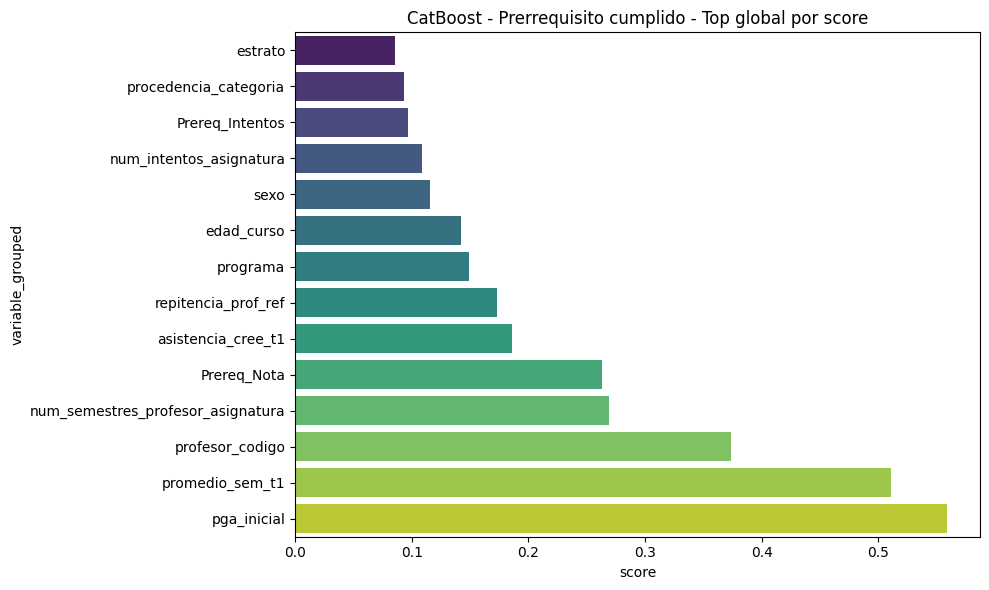

### Por departamento

,depto,variable_grouped,freq,mean_weight,median_weight,total_weight,n_rows,score
0,Dpto. Arquitectura y Urbanismo,Prereq_Nota,1,0.163000,0.163,8.639,53,0.112983
1,Dpto. Arquitectura y Urbanismo,promedio_sem_t1,1,0.156000,0.156,8.268,53,0.108131
2,Dpto. Arquitectura y Urbanismo,pga_inicial,1,0.149000,0.149,7.897,53,0.103279
3,Dpto. Arquitectura y Urbanismo,profesor_codigo,1,0.104000,0.104,5.512,53,0.072087
4,Dpto. Arquitectura y Urbanismo,asistencia_cree_t1,1,0.072000,0.072,3.816,53,0.049907
5,Dpto. Arquitectura y Urbanismo,sexo,1,0.064000,0.064,3.392,53,0.044361
6,Dpto. Arquitectura y Urbanismo,num_intentos_asignatura,1,0.045000,0.045,2.385,53,0.031192
7,Dpto. Arquitectura y Urbanismo,num_semestres_profesor_asignatura,1,0.044000,0.044,2.332,53,0.030498
8,Dpto. Arquitectura y Urbanismo,procedencia_categoria,1,0.042000,0.042,2.226,53,0.029112
9,Dpto. Arquitectura y Urbanismo,estrato,1,0.039000,0.039,2.067,53,0.027033


### CatBoost - Resumen por departamento
- **Dpto. Arquitectura y Urbanismo**: Prereq_Nota (score=0.113), promedio_sem_t1 (score=0.108), pga_inicial (score=0.103), profesor_codigo (score=0.072), asistencia_cree_t1 (score=0.050)
- **Dpto. Comunicación Social**: pga_inicial (score=0.212), profesor_codigo (score=0.199), promedio_sem_t1 (score=0.175), Prereq_Nota (score=0.056), edad_curso (score=0.053)
- **Dpto. Cs Politica y Rel Intern**: pga_inicial (score=0.082), num_semestres_profesor_asignatura (score=0.081), profesor_codigo (score=0.075), promedio_sem_t1 (score=0.062), edad_curso (score=0.021)
- **Dpto. Derecho**: pga_inicial (score=0.498), profesor_codigo (score=0.314), promedio_sem_t1 (score=0.269), num_semestres_profesor_asignatura (score=0.264), Prereq_Nota (score=0.139)
- **Dpto. Emprendim y Management**: pga_inicial (score=0.158), profesor_codigo (score=0.151), num_semestres_profesor_asignatura (score=0.117), promedio_sem_t1 (score=0.105), asistencia_cree_t1 (score=0.077)
- **Dpto. Español**: promedio_sem_t1 (score=0.101), pga_inicial (score=0.060), programa (score=0.056), profesor_codigo (score=0.047), asistencia_cree_t1 (score=0.044)
- **Dpto. Finanzas y Contaduría**: pga_inicial (score=0.166), promedio_sem_t1 (score=0.140), asistencia_cree_t1 (score=0.059), profesor_codigo (score=0.059), num_semestres_profesor_asignatura (score=0.053)
- **Dpto. Física**: promedio_sem_t1 (score=0.228), pga_inicial (score=0.161), num_semestres_profesor_asignatura (score=0.111), Prereq_Nota (score=0.068), repitencia_prof_ref (score=0.054)
- **Dpto. Ing. Civil y Ambiental**: pga_inicial (score=0.267), promedio_sem_t1 (score=0.201), profesor_codigo (score=0.191), num_semestres_profesor_asignatura (score=0.067), asistencia_cree_t1 (score=0.061)
- **Dpto. Ingeniería Industrial**: pga_inicial (score=0.488), promedio_sem_t1 (score=0.205), profesor_codigo (score=0.133), num_semestres_profesor_asignatura (score=0.091), repitencia_prof_ref (score=0.078)
- **Dpto. Ingeniería Mecánica**: promedio_sem_t1 (score=0.242), pga_inicial (score=0.213), profesor_codigo (score=0.126), Prereq_Nota (score=0.084), num_semestres_profesor_asignatura (score=0.068)
- **Dpto. Ingeniería de Sistemas**: pga_inicial (score=0.313), promedio_sem_t1 (score=0.266), profesor_codigo (score=0.230), Prereq_Nota (score=0.139), repitencia_prof_ref (score=0.111)
- **Dpto. Lenguas Extranjeras**: Prereq_Nota (score=0.337), pga_inicial (score=0.262), profesor_codigo (score=0.225), promedio_sem_t1 (score=0.182), num_semestres_profesor_asignatura (score=0.172)
- **Dpto. Matematicas y estadístic**: promedio_sem_t1 (score=0.361), pga_inicial (score=0.313), profesor_codigo (score=0.196), num_semestres_profesor_asignatura (score=0.170), Prereq_Nota (score=0.167)
- **Dpto. Medicina**: promedio_sem_t1 (score=0.185), profesor_codigo (score=0.150), pga_inicial (score=0.120), Prereq_Nota (score=0.108), asistencia_cree_t1 (score=0.045)
- **Dpto. Mercadeo y Neg. Internac**: pga_inicial (score=0.146), promedio_sem_t1 (score=0.121), num_semestres_profesor_asignatura (score=0.109), repitencia_prof_ref (score=0.057), asistencia_cree_t1 (score=0.043)
- **Dpto. Psicología**: pga_inicial (score=0.058), promedio_sem_t1 (score=0.027), num_semestres_profesor_asignatura (score=0.021), sexo (score=0.021), asistencia_cree_t1 (score=0.020)
- **Dpto. Salud Pública**: profesor_codigo (score=0.024), pga_inicial (score=0.021), Prereq_Nota (score=0.020), asistencia_cree_t1 (score=0.014), promedio_sem_t1 (score=0.014)
- **Dpto. de Economía**: pga_inicial (score=0.133), profesor_codigo (score=0.106), promedio_sem_t1 (score=0.090), Prereq_Nota (score=0.035), asistencia_cree_t1 (score=0.028)

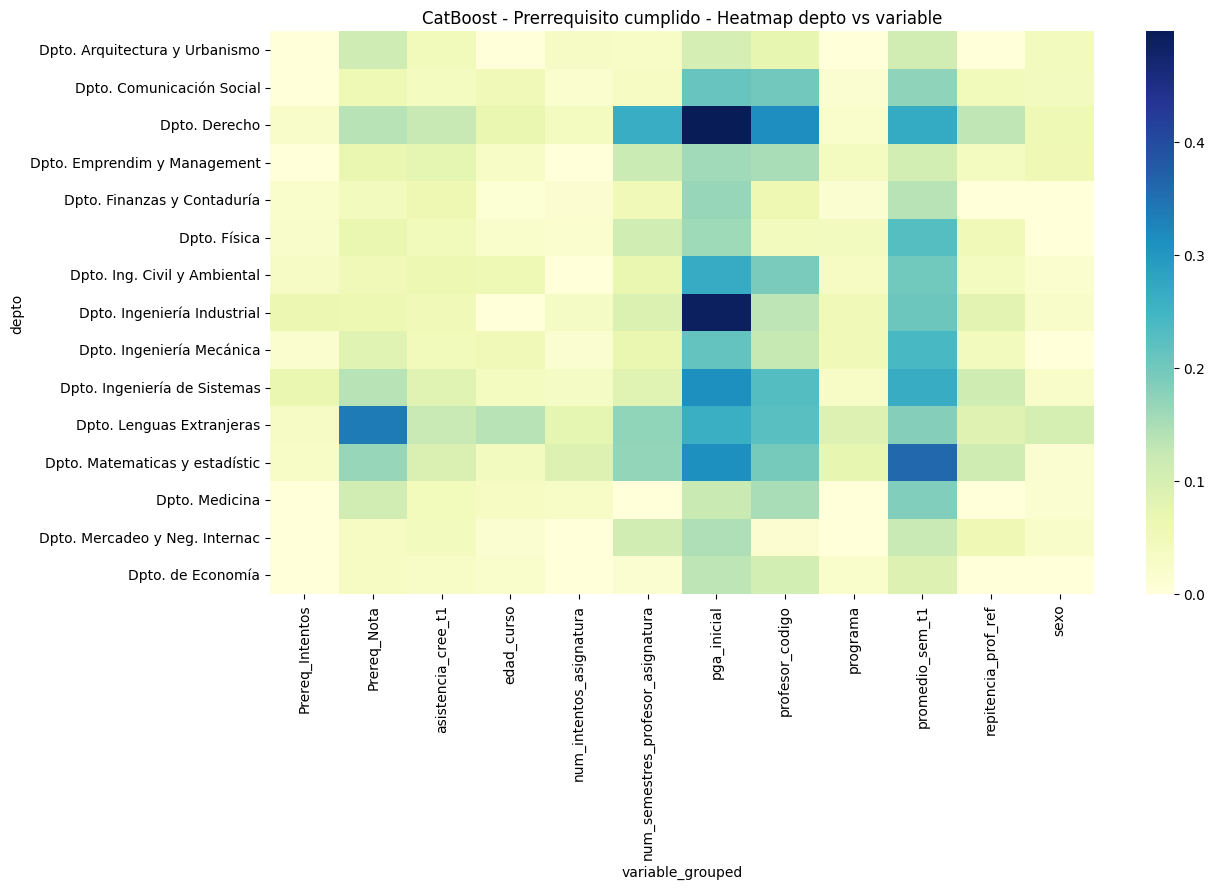

### Por asignatura

,row_idx,model,depto,asignatura,categoria_prereq,variable,variable_grouped,weight,rank_in_course
0,12358,CatBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,pga_inicial,pga_inicial,0.213,1.0
1,12359,CatBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,pga_inicial,pga_inicial,0.213,2.0
2,12360,CatBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,pga_inicial,pga_inicial,0.213,3.0
3,12361,CatBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,pga_inicial,pga_inicial,0.213,4.0
4,12362,CatBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,pga_inicial,pga_inicial,0.213,5.0
5,12363,CatBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,pga_inicial,pga_inicial,0.213,6.0
6,12364,CatBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,pga_inicial,pga_inicial,0.213,7.0
7,12365,CatBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,pga_inicial,pga_inicial,0.213,8.0
8,12366,CatBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,pga_inicial,pga_inicial,0.213,9.0
9,12367,CatBoost,Dpto. Derecho,ADMINISTRATIVO I,Prerrequisito cumplido,pga_inicial,pga_inicial,0.213,10.0


### Direccional por registro

Reporte de parsing (direccional): {'total_rows': 10363, 'parsed_rows': 10363, 'not_parsed_rows': 0}


#### Top efecto neto positivo (solo net_effect > 0)

,variable_grouped,total_count,pos_count,neg_count,mean_signed,median_signed,mean_pos,mean_neg,net_effect,net_rate
0,asistencia_cree_t1,10043,5915,4128,0.007863,0.010,0.040825,-0.039367,0.072457,0.177935
1,repitencia_prof_ref,8967,5003,3964,0.004531,0.005,0.036764,-0.036151,0.041238,0.115869
2,edad_curso,9666,5617,4049,0.000867,0.005,0.023825,-0.030981,0.007957,0.162218
3,procedencia_categoria,9520,4889,4631,0.000030,0.001,0.017803,-0.018732,0.000278,0.027101


#### Top efecto neto negativo (solo net_effect < 0)

,variable_grouped,total_count,pos_count,neg_count,mean_signed,median_signed,mean_pos,mean_neg,net_effect,net_rate
0,pga_inicial,10266,4293,5973,-0.028689,-0.028,0.113486,-0.130875,-0.264988,-0.163647
1,promedio_sem_t1,10284,4795,5489,-0.014768,-0.010,0.105094,-0.119475,-0.136433,-0.067483
2,num_semestres_profesor_asignatura,9106,4195,4911,-0.014197,-0.005,0.048689,-0.067914,-0.129429,-0.078629
3,Prereq_Nota,27974,12485,15489,-0.010610,-0.007,0.041995,-0.053013,-0.108637,-0.107385
4,profesor_codigo,10149,5001,5148,-0.011037,0.000,0.070425,-0.090173,-0.101822,-0.014484
5,num_intentos_asignatura,8931,6707,2224,-0.004064,0.005,0.010756,-0.048759,-0.036972,0.501959
6,Prereq_Intentos,15291,11571,3720,-0.002872,0.002,0.005276,-0.028218,-0.027675,0.513439
7,programa,8032,4204,3828,-0.003030,0.000,0.029461,-0.038713,-0.027244,0.046813
8,sexo,9487,4666,4821,-0.000598,0.000,0.016218,-0.016873,-0.005478,-0.016338
9,estrato,9616,4651,4965,-0.000162,-0.001,0.018814,-0.017938,-0.001483,-0.032654


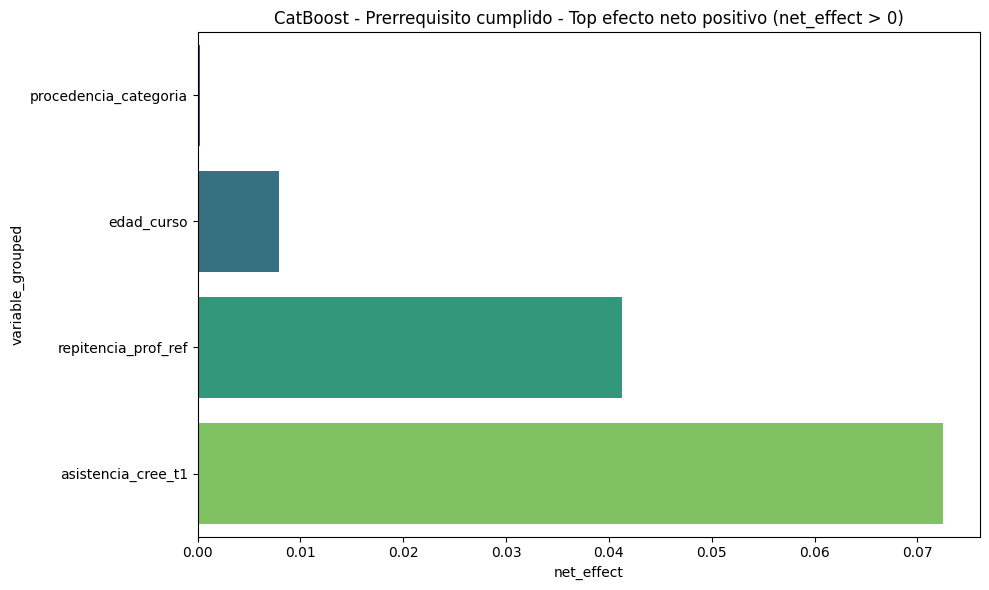

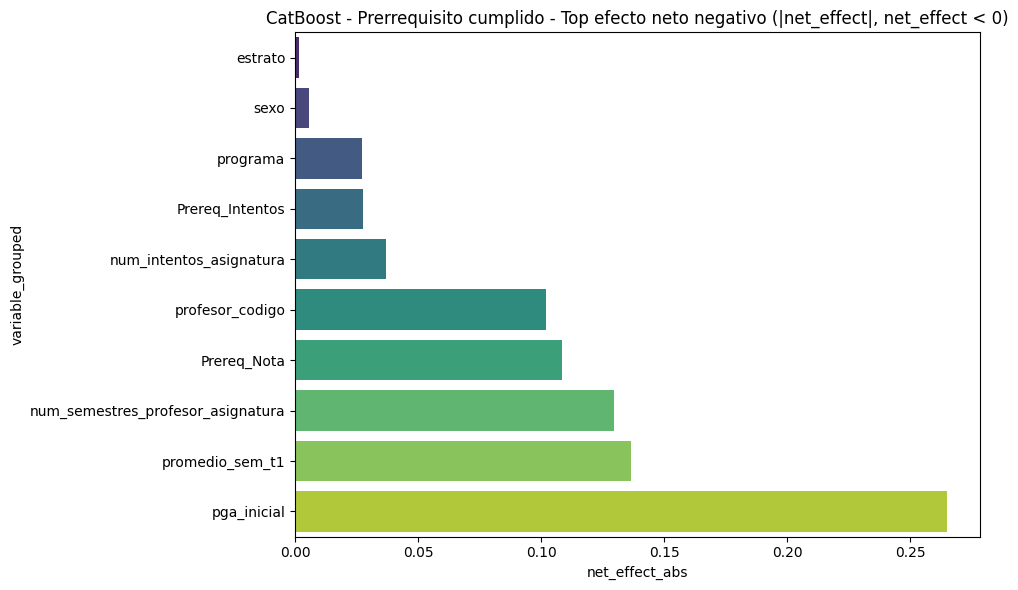

#### Direccional por departamento

,depto,variable_grouped,total_count,pos_count,neg_count,mean_signed,net_effect,net_rate
0,Dpto. Arquitectura y Urbanismo,profesor_codigo,53,49,4,0.097094,0.387308,0.849057
1,Dpto. Arquitectura y Urbanismo,procedencia_categoria,53,37,16,0.020132,0.080307,0.396226
2,Dpto. Arquitectura y Urbanismo,asistencia_cree_t1,53,30,23,0.013302,0.053061,0.132075
3,Dpto. Arquitectura y Urbanismo,sexo,53,38,15,0.006509,0.025966,0.433962
4,Dpto. Arquitectura y Urbanismo,num_intentos_asignatura,53,48,5,0.005868,0.023407,0.811321
5,Dpto. Arquitectura y Urbanismo,num_semestres_profesor_asignatura,52,32,20,0.003731,0.014812,0.230769
6,Dpto. Arquitectura y Urbanismo,pga_inicial,52,25,27,0.003365,0.013362,-0.038462
7,Dpto. Arquitectura y Urbanismo,Prereq_Intentos,44,44,0,0.003364,0.012804,1.000000
8,Dpto. Arquitectura y Urbanismo,programa,53,0,53,0.000000,0.000000,-1.000000
9,Dpto. Arquitectura y Urbanismo,repitencia_prof_ref,51,24,27,-0.000059,-0.000232,-0.058824


## CatBoost - No tiene pre requisito

Filas del segmento: 10337
Reporte de parsing (general): {'total_rows': 10337, 'parsed_rows': 7540, 'not_parsed_rows': 2797, 'asignaturas_unicas': 60}


**Ejemplos no parseados (general):**

,Descripcion_Materia,Categoria_Prerrequisito,interpretacion_general_cat
4373,COMPETENCIA COMUNICATIVA I,No tiene pre requisito,NaN
4374,COMPETENCIA COMUNICATIVA I,No tiene pre requisito,NaN
4375,COMPETENCIA COMUNICATIVA I,No tiene pre requisito,NaN
4376,COMPETENCIA COMUNICATIVA I,No tiene pre requisito,NaN
4377,COMPETENCIA COMUNICATIVA I,No tiene pre requisito,NaN


### Global

,variable_grouped,freq,mean_weight,median_weight,total_weight,n_rows,score
0,profesor_codigo,52,0.127894,0.107,872.367,6821,0.507778
1,pga_inicial,57,0.124814,0.097,913.886,7322,0.506799
2,saber11_matematicas,15,0.131075,0.059,282.466,2155,0.363416
3,promedio_sem_t1,44,0.091920,0.072,491.588,5348,0.349908
4,num_semestres_profesor_asignatura,48,0.057557,0.046,353.517,6142,0.224003
5,programa,42,0.053769,0.048,331.005,6156,0.202238
6,saber11_lectura_critica,9,0.082731,0.045,76.195,921,0.190495
7,asistencia_cree_t1,52,0.047914,0.042,333.819,6967,0.190234
8,saber11_ingles,9,0.076190,0.036,91.123,1196,0.175433
9,saber11_sociales,10,0.072379,0.053,72.813,1006,0.173557


### CatBoost
- **profesor_codigo**: score=0.5078, freq=52, mean=0.1279.
- **pga_inicial**: score=0.5068, freq=57, mean=0.1248.
- **saber11_matematicas**: score=0.3634, freq=15, mean=0.1311.
- **promedio_sem_t1**: score=0.3499, freq=44, mean=0.0919.
- **num_semestres_profesor_asignatura**: score=0.2240, freq=48, mean=0.0576.

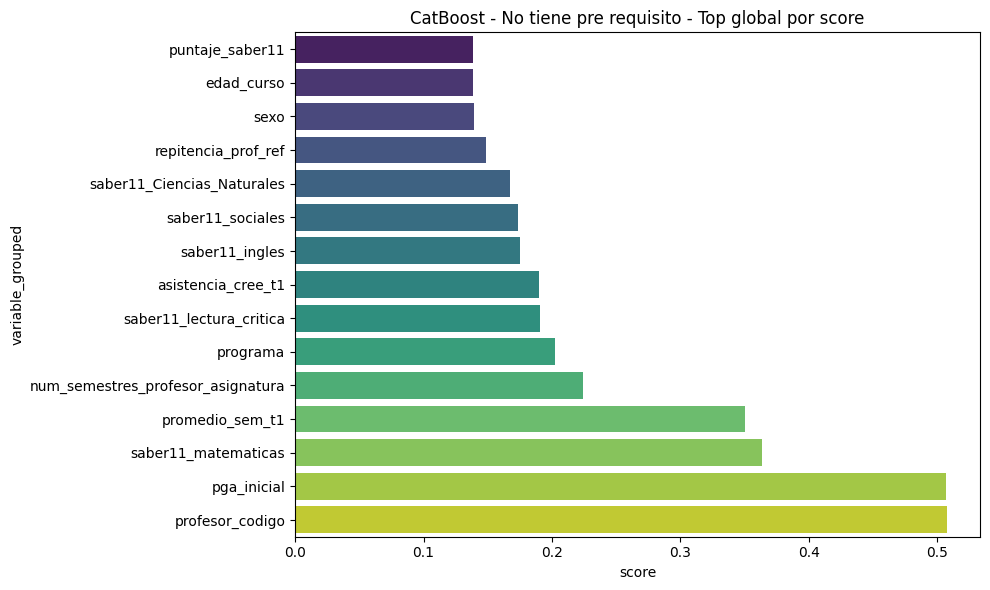

### Por departamento

,depto,variable_grouped,freq,mean_weight,median_weight,total_weight,n_rows,score
0,Centro de Acompañamiento Estud,programa,1,0.210000,0.210,16.800,80,0.145561
1,Centro de Acompañamiento Estud,pga_inicial,1,0.179000,0.179,14.320,80,0.124073
2,Centro de Acompañamiento Estud,promedio_sem_t1,1,0.119000,0.119,9.520,80,0.082485
3,Centro de Acompañamiento Estud,asistencia_cree_t1,1,0.105000,0.105,8.400,80,0.072780
4,Centro de Acompañamiento Estud,num_semestres_profesor_asignatura,1,0.091000,0.091,7.280,80,0.063076
5,Centro de Acompañamiento Estud,edad_curso,1,0.071000,0.071,5.680,80,0.049213
6,Centro de Acompañamiento Estud,profesor_codigo,1,0.064000,0.064,5.120,80,0.044361
7,Centro de Acompañamiento Estud,estrato,1,0.051000,0.051,4.080,80,0.035351
8,Centro de Acompañamiento Estud,procedencia_categoria,1,0.049000,0.049,3.920,80,0.033964
9,Centro de Acompañamiento Estud,Tipo_colegio,1,0.047000,0.047,3.760,80,0.032578


### CatBoost - Resumen por departamento
- **Centro de Acompañamiento Estud**: programa (score=0.146), pga_inicial (score=0.124), promedio_sem_t1 (score=0.082), asistencia_cree_t1 (score=0.073), num_semestres_profesor_asignatura (score=0.063)
- **Dpto. Comunicación Social**: profesor_codigo (score=0.150), pga_inicial (score=0.097), promedio_sem_t1 (score=0.063), num_semestres_profesor_asignatura (score=0.037), repitencia_prof_ref (score=0.025)
- **Dpto. Derecho**: pga_inicial (score=0.378), promedio_sem_t1 (score=0.335), profesor_codigo (score=0.318), num_semestres_profesor_asignatura (score=0.167), repitencia_prof_ref (score=0.137)
- **Dpto. Educación**: profesor_codigo (score=0.112), pga_inicial (score=0.066), promedio_sem_t1 (score=0.037), programa (score=0.035), asistencia_cree_t1 (score=0.028)
- **Dpto. Emprendim y Management**: promedio_sem_t1 (score=0.131), pga_inicial (score=0.105), profesor_codigo (score=0.099), num_semestres_profesor_asignatura (score=0.084), asistencia_cree_t1 (score=0.081)
- **Dpto. Español**: pga_inicial (score=0.083), promedio_sem_t1 (score=0.082), num_semestres_profesor_asignatura (score=0.078), Tipo_colegio (score=0.031), profesor_codigo (score=0.023)
- **Dpto. Historia y Cs. Sociales**: profesor_codigo (score=0.338), pga_inicial (score=0.242), promedio_sem_t1 (score=0.194), num_semestres_profesor_asignatura (score=0.157), programa (score=0.148)
- **Dpto. Humanidades y Filosofía**: profesor_codigo (score=0.410), pga_inicial (score=0.197), promedio_sem_t1 (score=0.139), programa (score=0.128), asistencia_cree_t1 (score=0.092)
- **Dpto. Ing. Civil y Ambiental**: profesor_codigo (score=0.116), saber11_matematicas (score=0.086), pga_inicial (score=0.082), num_intentos_asignatura (score=0.078), repitencia_prof_ref (score=0.076)
- **Dpto. Ingeniería Industrial**: pga_inicial (score=0.222), programa (score=0.136), promedio_sem_t1 (score=0.111), repitencia_prof_ref (score=0.095), num_semestres_profesor_asignatura (score=0.057)
- **Dpto. Ingeniería Mecánica**: pga_inicial (score=0.123), promedio_sem_t1 (score=0.099), profesor_codigo (score=0.075), programa (score=0.037), asistencia_cree_t1 (score=0.026)
- **Dpto. Ingeniería de Sistemas**: saber11_matematicas (score=0.344), pga_inicial (score=0.204), saber11_ingles (score=0.126), saber11_lectura_critica (score=0.123), saber11_sociales (score=0.077)
- **Dpto. Lenguas Extranjeras**: puntaje_saber11 (score=0.244), profesor_codigo (score=0.225), saber11_matematicas (score=0.214), edad_curso (score=0.194), pga_inicial (score=0.144)
- **Dpto. Matematicas y estadístic**: pga_inicial (score=0.272), saber11_matematicas (score=0.147), promedio_sem_t1 (score=0.118), saber11_Ciencias_Naturales (score=0.117), num_semestres_profesor_asignatura (score=0.106)
- **Dpto. Mercadeo y Neg. Internac**: promedio_sem_t1 (score=0.066), pga_inicial (score=0.054), estrato (score=0.020), repitencia_prof_ref (score=0.015), profesor_codigo (score=0.013)
- **Dpto. Psicología**: promedio_sem_t1 (score=0.121), num_semestres_profesor_asignatura (score=0.116), pga_inicial (score=0.089), repitencia_prof_ref (score=0.036), asistencia_cree_t1 (score=0.034)
- **Dpto. Química y Biología**: profesor_codigo (score=0.194), pga_inicial (score=0.188), promedio_sem_t1 (score=0.121), programa (score=0.079), asistencia_cree_t1 (score=0.074)
- **Dpto. Salud Pública**: profesor_codigo (score=0.067), pga_inicial (score=0.060), num_semestres_profesor_asignatura (score=0.029), promedio_sem_t1 (score=0.021), asistencia_cree_t1 (score=0.010)
- **Dpto. de Economía**: pga_inicial (score=0.132), profesor_codigo (score=0.068), saber11_matematicas (score=0.038), sexo (score=0.034), asistencia_cree_t1 (score=0.028)
- **Dpto.Ing Eléctrica-Electrónica**: num_semestres_profesor_asignatura (score=0.069), programa (score=0.049), promedio_sem_t1 (score=0.047), edad_curso (score=0.044), pga_inicial (score=0.043)

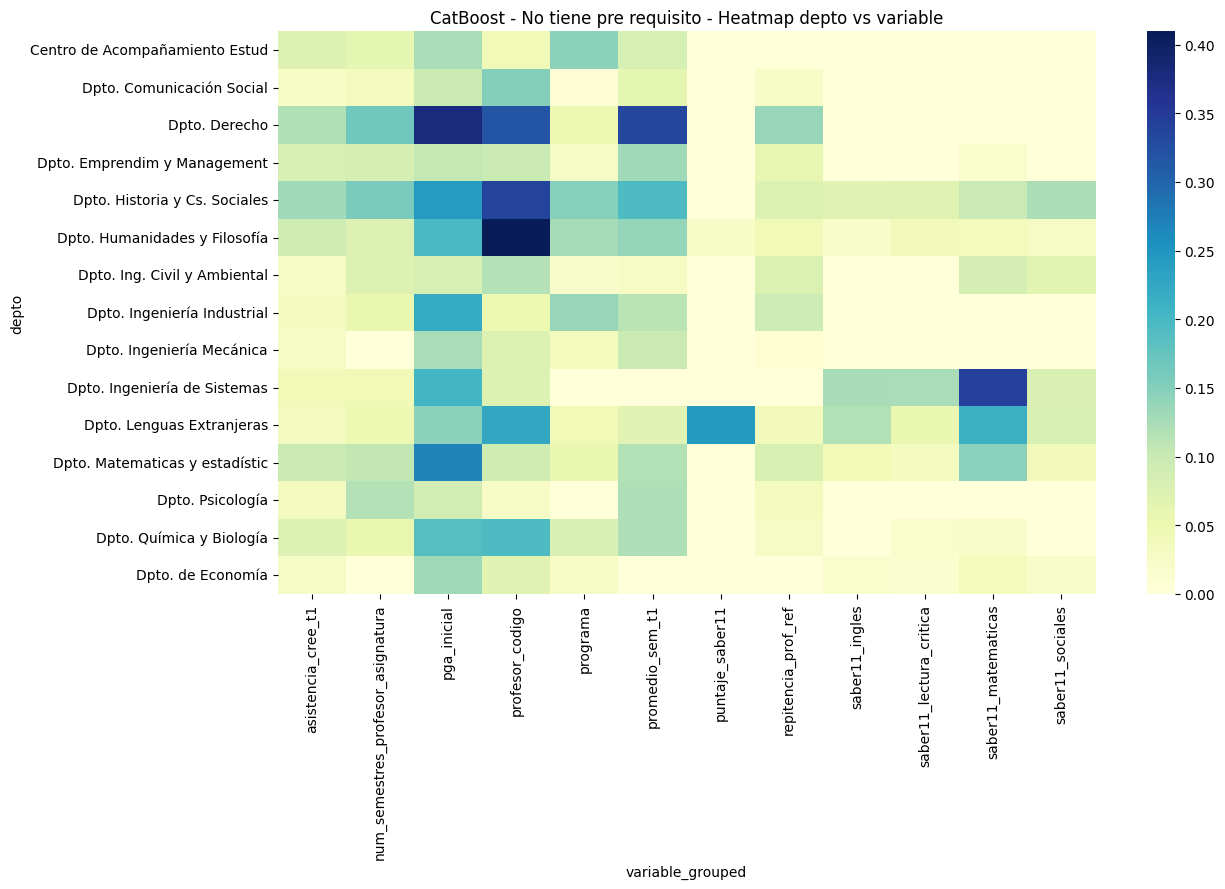

### Por asignatura

,row_idx,model,depto,asignatura,categoria_prereq,variable,variable_grouped,weight,rank_in_course
0,7439,CatBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,pga_inicial,pga_inicial,0.131,1.0
1,7440,CatBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,pga_inicial,pga_inicial,0.131,2.0
2,7441,CatBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,pga_inicial,pga_inicial,0.131,3.0
3,7442,CatBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,pga_inicial,pga_inicial,0.131,4.0
4,7443,CatBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,pga_inicial,pga_inicial,0.131,5.0
5,7444,CatBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,pga_inicial,pga_inicial,0.131,6.0
6,7445,CatBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,pga_inicial,pga_inicial,0.131,7.0
7,7446,CatBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,pga_inicial,pga_inicial,0.131,8.0
8,7447,CatBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,pga_inicial,pga_inicial,0.131,9.0
9,7448,CatBoost,Dpto. Matematicas y estadístic,ALGEBRA LINEAL,No tiene pre requisito,pga_inicial,pga_inicial,0.131,10.0


### Direccional por registro

Reporte de parsing (direccional): {'total_rows': 10337, 'parsed_rows': 7540, 'not_parsed_rows': 2797}


**Ejemplos no parseados (direccional):**

,Descripcion_Materia,Categoria_Prerrequisito,interpretacion_registro_cat
4373,COMPETENCIA COMUNICATIVA I,No tiene pre requisito,NaN
4374,COMPETENCIA COMUNICATIVA I,No tiene pre requisito,NaN
4375,COMPETENCIA COMUNICATIVA I,No tiene pre requisito,NaN
4376,COMPETENCIA COMUNICATIVA I,No tiene pre requisito,NaN
4377,COMPETENCIA COMUNICATIVA I,No tiene pre requisito,NaN


#### Top efecto neto positivo (solo net_effect > 0)

,variable_grouped,total_count,pos_count,neg_count,mean_signed,median_signed,mean_pos,mean_neg,net_effect,net_rate
0,años_saber11_vs_clase,1947,1230,717,0.006291,0.009,0.020718,-0.018459,0.047649,0.263482
1,repitencia_prof_ref,7192,4297,2895,0.003975,0.008,0.032230,-0.037963,0.035301,0.194939
2,procedencia_categoria,6999,3782,3217,0.000580,0.002,0.016365,-0.017977,0.005136,0.080726
3,Tipo_calendario,6964,3516,3448,0.000023,-0.000,0.015327,-0.015584,0.000199,0.009765


#### Top efecto neto negativo (solo net_effect < 0)

,variable_grouped,total_count,pos_count,neg_count,mean_signed,median_signed,mean_pos,mean_neg,net_effect,net_rate
0,saber11_matematicas,2134,834,1300,-0.086577,-0.0220,0.058512,-0.179657,-0.663717,-0.218369
1,puntaje_saber11,216,38,178,-0.089556,-0.0355,0.032395,-0.115590,-0.481800,-0.648148
2,saber11_lectura_critica,1947,843,1104,-0.030561,-0.0050,0.022368,-0.070977,-0.231489,-0.134052
3,saber11_ingles,2004,1013,991,-0.027440,0.0010,0.024611,-0.080646,-0.208634,0.010978
4,saber11_sociales,1982,854,1128,-0.021957,-0.0050,0.027979,-0.059763,-0.166706,-0.138244
5,saber11_Ciencias_Naturales,2122,940,1182,-0.020398,-0.0110,0.044522,-0.072027,-0.156262,-0.114043
6,profesor_codigo,7371,3491,3880,-0.011413,-0.0040,0.113689,-0.123974,-0.101641,-0.052774
7,pga_inicial,7280,3297,3983,-0.011180,-0.0160,0.126177,-0.124879,-0.099424,-0.094231
8,num_semestres_profesor_asignatura,7300,3719,3581,-0.009858,0.0010,0.039939,-0.061574,-0.087690,0.018904
9,promedio_sem_t1,5332,2631,2701,-0.007016,-0.0010,0.086381,-0.097992,-0.060205,-0.013128


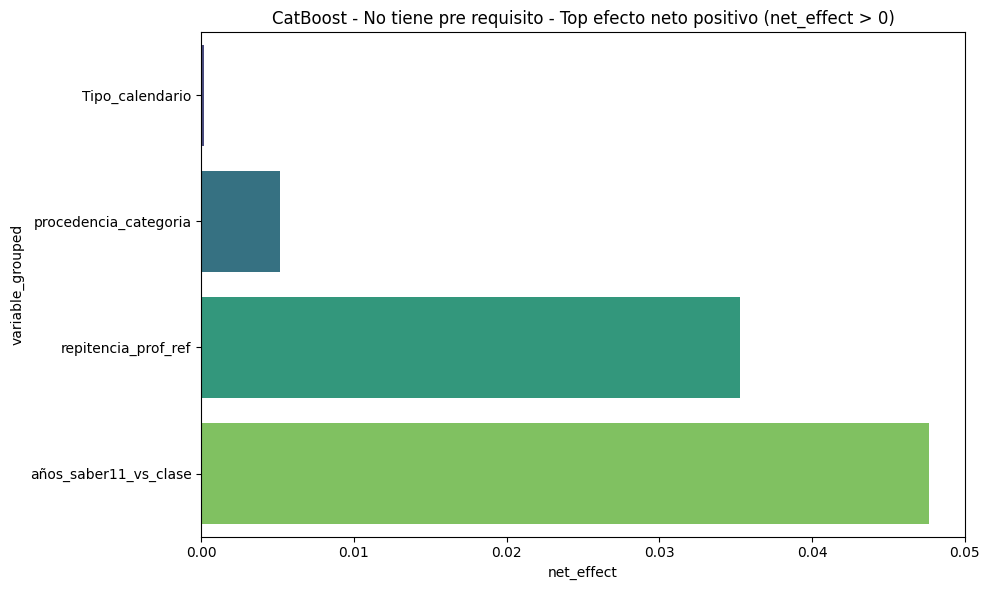

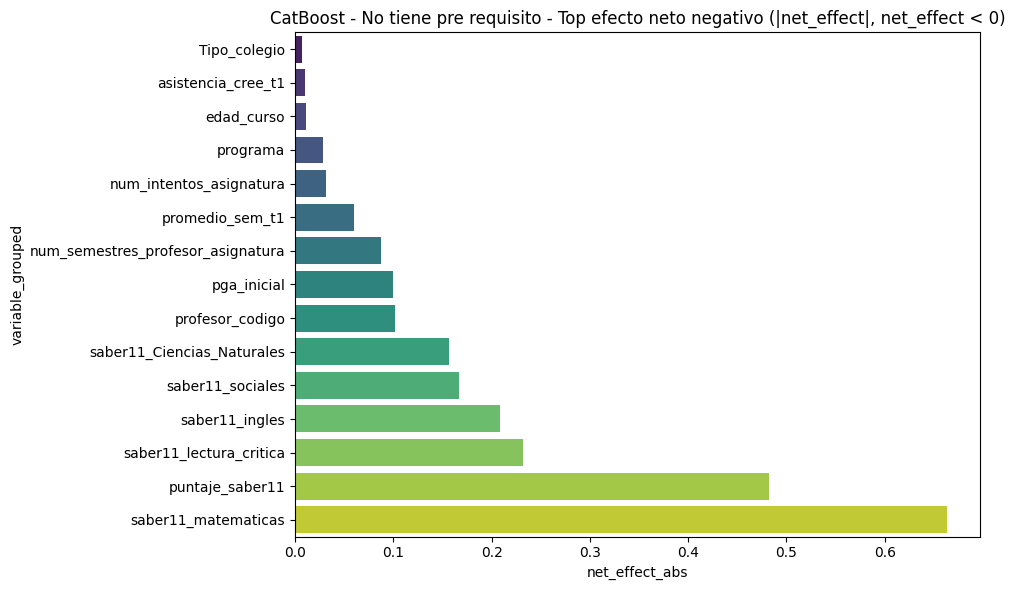

#### Direccional por departamento

,depto,variable_grouped,total_count,pos_count,neg_count,mean_signed,net_effect,net_rate
0,Centro de Acompañamiento Estud,profesor_codigo,79,67,12,0.054241,0.237683,0.696203
1,Centro de Acompañamiento Estud,edad_curso,80,42,38,0.011900,0.052294,0.050000
2,Centro de Acompañamiento Estud,estrato,78,39,39,0.004821,0.021063,0.000000
3,Centro de Acompañamiento Estud,sexo,80,69,11,0.001025,0.004504,0.725000
4,Centro de Acompañamiento Estud,num_intentos_asignatura,78,29,49,-0.000487,-0.002129,-0.256410
5,Centro de Acompañamiento Estud,procedencia_categoria,79,35,44,-0.007848,-0.034391,-0.113924
6,Centro de Acompañamiento Estud,Tipo_calendario,79,17,62,-0.010316,-0.045207,-0.569620
7,Centro de Acompañamiento Estud,promedio_sem_t1,80,36,44,-0.011600,-0.050976,-0.100000
8,Centro de Acompañamiento Estud,asistencia_cree_t1,80,35,45,-0.020487,-0.090031,-0.125000
9,Centro de Acompañamiento Estud,Tipo_colegio,79,28,51,-0.024734,-0.108386,-0.291139


Resumen CAT listo por categorias.


In [77]:
# CAT segmentado por categoria de prerequisito
results_cat = run_model_segmented(df, "CatBoost", "interpretacion_general_cat", "interpretacion_registro_cat")
display_segmented_results(results_cat, "CatBoost")

# Dataframes de salida consolidados (incluyen categoria_prereq)
global_summary_cat = add_category_column(results_cat, "global_top")
global_summary_cat_full = add_category_column(results_cat, "global_full")
dept_summary_cat = add_category_column(results_cat, "dept")
course_summary_cat = add_category_column(results_cat, "course")
directional_summary_cat = add_category_column(results_cat, "directional")
directional_summary_cat_pos = add_category_column(results_cat, "directional_pos")
directional_summary_cat_neg = add_category_column(results_cat, "directional_neg")
directional_dept_summary_cat = add_category_column(results_cat, "directional_dept")

print("Resumen CAT listo por categorias.")

## 11. Comparativo XGB vs CAT (tabla y bullets)

In [78]:
comp_parts = []

for cat_value in CATEGORY_ORDER:
    xgb_seg = global_summary_xgb_full[global_summary_xgb_full["categoria_prereq"] == cat_value].copy()
    cat_seg = global_summary_cat_full[global_summary_cat_full["categoria_prereq"] == cat_value].copy()

    xgb_base = xgb_seg[["variable_grouped", "score", "freq", "mean_weight", "total_weight"]] if not xgb_seg.empty else pd.DataFrame(columns=["variable_grouped", "score", "freq", "mean_weight", "total_weight"])
    cat_base = cat_seg[["variable_grouped", "score", "freq", "mean_weight", "total_weight"]] if not cat_seg.empty else pd.DataFrame(columns=["variable_grouped", "score", "freq", "mean_weight", "total_weight"])

    comp_seg = xgb_base.merge(
        cat_base,
        on="variable_grouped",
        how="outer",
        suffixes=("_xgb", "_cat"),
    ).fillna(0)

    comp_seg["categoria_prereq"] = cat_value
    comp_seg["delta_score_xgb_minus_cat"] = comp_seg["score_xgb"] - comp_seg["score_cat"]
    comp_seg = comp_seg.sort_values("delta_score_xgb_minus_cat", ascending=False).reset_index(drop=True)
    comp_parts.append(comp_seg)

comp = pd.concat(comp_parts, ignore_index=True) if comp_parts else pd.DataFrame()

for cat_value in CATEGORY_ORDER:
    display(Markdown(f"### Comparativo global (XGB vs CAT) - {cat_value}"))
    seg = comp[comp["categoria_prereq"] == cat_value].copy()
    display(seg.head(30))

    bullets = []
    for _, r in seg.head(5).iterrows():
        bullets.append(f"- **{r['variable_grouped']}** favorece mas XGB (delta score={r['delta_score_xgb_minus_cat']:.4f}).")
    for _, r in seg.tail(5).iterrows():
        bullets.append(f"- **{r['variable_grouped']}** favorece mas CAT (delta score={r['delta_score_xgb_minus_cat']:.4f}).")

    if bullets:
        display(Markdown("#### Hallazgos clave\n" + "\n".join(bullets)))
    else:
        display(Markdown("#### Hallazgos clave\n- Sin datos suficientes para comparar."))

### Comparativo global (XGB vs CAT) - Prerrequisito cumplido

,variable_grouped,score_xgb,freq_xgb,mean_weight_xgb,total_weight_xgb,score_cat,freq_cat,mean_weight_cat,total_weight_cat,categoria_prereq,delta_score_xgb_minus_cat
0,profesor_codigo,0.591343,90,0.131093,1312.637,0.374084,87,0.083550,802.586,Prerrequisito cumplido,0.217260
1,programa,0.309932,41,0.082921,545.124,0.149389,39,0.040497,254.524,Prerrequisito cumplido,0.160543
2,pga_inicial,0.636260,95,0.139398,1444.579,0.559318,95,0.122541,1269.888,Prerrequisito cumplido,0.076942
3,promedio_sem_t1,0.545012,95,0.119406,1237.408,0.511210,95,0.112001,1160.662,Prerrequisito cumplido,0.033803
4,estrato,0.084792,47,0.021903,89.059,0.085626,38,0.023372,75.890,Prerrequisito cumplido,-0.000834
5,procedencia_categoria,0.085350,39,0.023137,71.054,0.093731,41,0.025077,84.135,Prerrequisito cumplido,-0.008381
6,num_intentos_asignatura,0.100459,19,0.033534,60.328,0.109155,27,0.032758,141.939,Prerrequisito cumplido,-0.008696
7,num_semestres_profesor_asignatura,0.246469,74,0.057086,474.100,0.269228,78,0.061616,528.173,Prerrequisito cumplido,-0.022760
8,asistencia_cree_t1,0.160339,86,0.035903,343.268,0.186069,84,0.041882,384.858,Prerrequisito cumplido,-0.025730
9,edad_curso,0.111274,56,0.027522,178.124,0.142250,52,0.035828,194.692,Prerrequisito cumplido,-0.030976


#### Hallazgos clave
- **profesor_codigo** favorece mas XGB (delta score=0.2173).
- **programa** favorece mas XGB (delta score=0.1605).
- **pga_inicial** favorece mas XGB (delta score=0.0769).
- **promedio_sem_t1** favorece mas XGB (delta score=0.0338).
- **estrato** favorece mas XGB (delta score=-0.0008).
- **edad_curso** favorece mas CAT (delta score=-0.0310).
- **repitencia_prof_ref** favorece mas CAT (delta score=-0.0310).
- **Prereq_Intentos** favorece mas CAT (delta score=-0.0333).
- **sexo** favorece mas CAT (delta score=-0.0419).
- **Prereq_Nota** favorece mas CAT (delta score=-0.0554).

### Comparativo global (XGB vs CAT) - No tiene pre requisito

,variable_grouped,score_xgb,freq_xgb,mean_weight_xgb,total_weight_xgb,score_cat,freq_cat,mean_weight_cat,total_weight_cat,categoria_prereq,delta_score_xgb_minus_cat
14,puntaje_saber11,0.399790,28,0.118727,318.664,0.138413,3,0.099844,21.766,No tiene pre requisito,0.261377
15,profesor_codigo,0.677848,80,0.154251,1505.181,0.507778,52,0.127894,872.367,No tiene pre requisito,0.170070
16,programa,0.271640,41,0.072676,496.380,0.202238,42,0.053769,331.005,No tiene pre requisito,0.069403
17,saber11_Ciencias_Naturales,0.235933,38,0.064400,295.080,0.166958,15,0.060217,124.469,No tiene pre requisito,0.068975
18,Tipo_colegio,0.112309,52,0.028287,145.934,0.084526,31,0.024389,91.117,No tiene pre requisito,0.027783
19,sexo,0.161146,58,0.039520,277.829,0.139023,35,0.038795,148.857,No tiene pre requisito,0.022123
20,pga_inicial,0.523702,60,0.127394,974.948,0.506799,57,0.124814,913.886,No tiene pre requisito,0.016903
21,años_saber11_vs_clase,0.053938,6,0.027719,12.113,0.038900,2,0.035409,6.586,No tiene pre requisito,0.015037
22,promedio_sem_t1,0.362708,44,0.095283,509.571,0.349908,44,0.091920,491.588,No tiene pre requisito,0.012800
23,procedencia_categoria,0.074621,40,0.020094,79.512,0.068243,32,0.019517,73.190,No tiene pre requisito,0.006378


#### Hallazgos clave
- **puntaje_saber11** favorece mas XGB (delta score=0.2614).
- **profesor_codigo** favorece mas XGB (delta score=0.1701).
- **programa** favorece mas XGB (delta score=0.0694).
- **saber11_Ciencias_Naturales** favorece mas XGB (delta score=0.0690).
- **Tipo_colegio** favorece mas XGB (delta score=0.0278).
- **saber11_sociales** favorece mas CAT (delta score=-0.0269).
- **saber11_lectura_critica** favorece mas CAT (delta score=-0.0290).
- **num_intentos_asignatura** favorece mas CAT (delta score=-0.0408).
- **Tipo_calendario** favorece mas CAT (delta score=-0.0548).
- **saber11_matematicas** favorece mas CAT (delta score=-0.0648).

## 12. Exportar resultados (CSV/Excel) a `BASE_DIR/output`

In [79]:
export_map = {
    "xgb_vs_cat.csv": comp,
}

# Exportes separados por categoria para evitar mezcla
for cat_value in CATEGORY_ORDER:
    suffix = "tiene_prereq" if cat_value == CAT_HAS else "no_tiene_prereq"

    export_map[f"general_xgb_{suffix}.csv"] = global_summary_xgb_full[global_summary_xgb_full["categoria_prereq"] == cat_value]
    export_map[f"departamentos_xgb_{suffix}.csv"] = dept_summary_xgb[dept_summary_xgb["categoria_prereq"] == cat_value]
    export_map[f"cursos_xgb_{suffix}.csv"] = course_summary_xgb[course_summary_xgb["categoria_prereq"] == cat_value]
    export_map[f"direccional_xgb_{suffix}.csv"] = directional_summary_xgb[directional_summary_xgb["categoria_prereq"] == cat_value]
    export_map[f"direccional_xgb_pos_{suffix}.csv"] = directional_summary_xgb_pos[directional_summary_xgb_pos["categoria_prereq"] == cat_value]
    export_map[f"direccional_xgb_neg_{suffix}.csv"] = directional_summary_xgb_neg[directional_summary_xgb_neg["categoria_prereq"] == cat_value]
    export_map[f"direccional_dept_xgb_{suffix}.csv"] = directional_dept_summary_xgb[directional_dept_summary_xgb["categoria_prereq"] == cat_value]

    export_map[f"general_cat_{suffix}.csv"] = global_summary_cat_full[global_summary_cat_full["categoria_prereq"] == cat_value]
    export_map[f"departamentos_cat_{suffix}.csv"] = dept_summary_cat[dept_summary_cat["categoria_prereq"] == cat_value]
    export_map[f"cursos_cat_{suffix}.csv"] = course_summary_cat[course_summary_cat["categoria_prereq"] == cat_value]
    export_map[f"direccional_cat_{suffix}.csv"] = directional_summary_cat[directional_summary_cat["categoria_prereq"] == cat_value]
    export_map[f"direccional_cat_pos_{suffix}.csv"] = directional_summary_cat_pos[directional_summary_cat_pos["categoria_prereq"] == cat_value]
    export_map[f"direccional_cat_neg_{suffix}.csv"] = directional_summary_cat_neg[directional_summary_cat_neg["categoria_prereq"] == cat_value]
    export_map[f"direccional_dept_cat_{suffix}.csv"] = directional_dept_summary_cat[directional_dept_summary_cat["categoria_prereq"] == cat_value]

for fname, dfx in export_map.items():
    out_path = os.path.join(OUTPUT_DIR, fname)
    dfx.to_csv(out_path, index=False, encoding="utf-8-sig")

excel_path = os.path.join(OUTPUT_DIR, "resumen_shap_xgb_cat.xlsx")
with pd.ExcelWriter(excel_path) as writer:
    for fname, dfx in export_map.items():
        sheet = fname.replace(".csv", "")[:31]
        dfx.to_excel(writer, sheet_name=sheet, index=False)

print(f"Archivos exportados en: {OUTPUT_DIR}")
display(pd.DataFrame({"archivo": sorted(export_map.keys())}))
print(f"Excel consolidado: {excel_path}")

Archivos exportados en: Resultados_Modelo_v2\output


,archivo
0,cursos_cat_no_tiene_prereq.csv
1,cursos_cat_tiene_prereq.csv
2,cursos_xgb_no_tiene_prereq.csv
3,cursos_xgb_tiene_prereq.csv
4,departamentos_cat_no_tiene_prereq.csv
5,departamentos_cat_tiene_prereq.csv
6,departamentos_xgb_no_tiene_prereq.csv
7,departamentos_xgb_tiene_prereq.csv
8,direccional_cat_neg_no_tiene_prereq.csv
9,direccional_cat_neg_tiene_prereq.csv


Excel consolidado: Resultados_Modelo_v2\output\resumen_shap_xgb_cat.xlsx


## 13. Relacion entre variable continua y contribucion SHAP firmada

Esta seccion evalua si la relacion entre el valor de una variable continua y su contribucion SHAP firmada es proporcional o inversa.

Reglas:
- Se usan variables que aparecen en SHAP y existen como columna en el dataset original.
- Solo variables continuas (numericas con suficiente variacion).
- Se excluyen variables de prerequisito (`Prereq*`).
- Se reporta correlacion de Spearman entre `valor_variable` y `contrib_signed`.

### XGBoost - Prerrequisito cumplido - Relacion variable continua vs contribucion

,model,categoria_prereq,variable,n_points,spearman_rho,pearson_r,slope,mean_signed,relation_label,abs_spearman
0,XGBoost,Prerrequisito cumplido,pga_inicial,10295,0.870485,0.800375,0.365399,-0.037136,Proporcional,0.870485
1,XGBoost,Prerrequisito cumplido,promedio_sem_t1,10313,0.857766,0.803812,0.265838,-0.009932,Proporcional,0.857766
2,XGBoost,Prerrequisito cumplido,edad_curso,9707,-0.507041,-0.484094,-0.010424,0.000870,Inversa,0.507041
3,XGBoost,Prerrequisito cumplido,asistencia_cree_t1,9827,0.315388,0.169173,0.000329,0.005305,Proporcional,0.315388
4,XGBoost,Prerrequisito cumplido,repitencia_prof_ref,5562,-0.038761,-0.035929,-0.013635,-0.004538,Debil o no monotona,0.038761


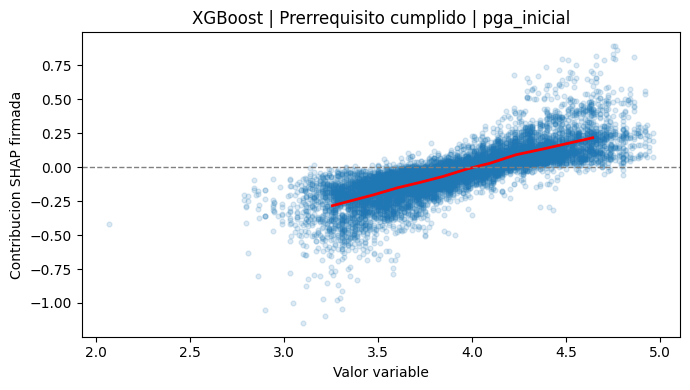

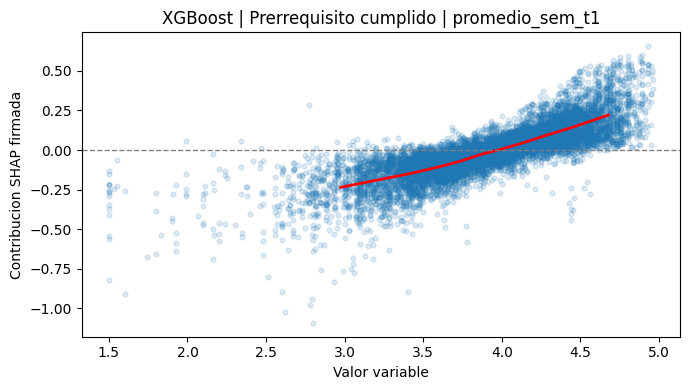

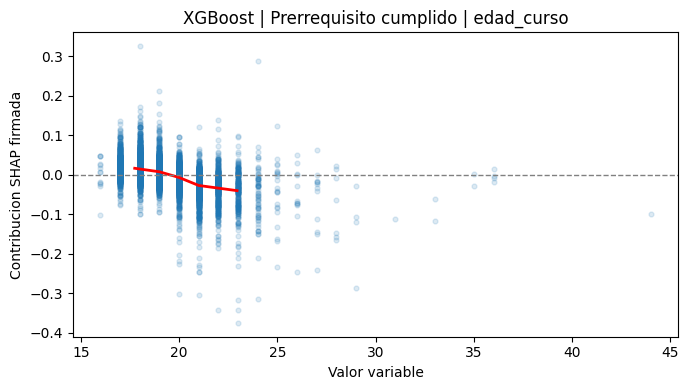

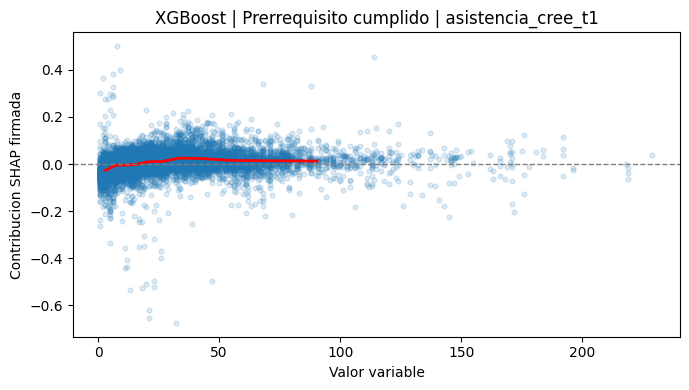

### XGBoost - No tiene pre requisito - Relacion variable continua vs contribucion

,model,categoria_prereq,variable,n_points,spearman_rho,pearson_r,slope,mean_signed,relation_label,abs_spearman
0,XGBoost,No tiene pre requisito,pga_inicial,7325,0.836964,0.689557,0.236483,-0.008308,Proporcional,0.836964
1,XGBoost,No tiene pre requisito,promedio_sem_t1,5323,0.799292,0.728032,0.201546,-0.007662,Proporcional,0.799292
2,XGBoost,No tiene pre requisito,puntaje_saber11,1947,0.733902,0.663401,0.001198,-0.015071,Proporcional,0.733902
3,XGBoost,No tiene pre requisito,saber11_matematicas,4458,0.719266,0.628508,0.004506,-0.005461,Proporcional,0.719266
4,XGBoost,No tiene pre requisito,saber11_Ciencias_Naturales,4438,0.680938,0.624228,0.004614,-0.005720,Proporcional,0.680938
5,XGBoost,No tiene pre requisito,asistencia_cree_t1,6852,0.536789,0.405372,0.000912,-0.006428,Proporcional,0.536789
6,XGBoost,No tiene pre requisito,edad_curso,9949,-0.402235,-0.374092,-0.009828,-0.002487,Inversa,0.402235
7,XGBoost,No tiene pre requisito,saber11_sociales,4307,0.380738,0.363127,0.001546,-0.007626,Proporcional,0.380738
8,XGBoost,No tiene pre requisito,saber11_ingles,4306,0.270040,0.280948,0.000924,0.000042,Proporcional,0.270040
9,XGBoost,No tiene pre requisito,repitencia_prof_ref,5543,-0.268040,-0.239434,-0.112756,-0.010674,Inversa,0.268040


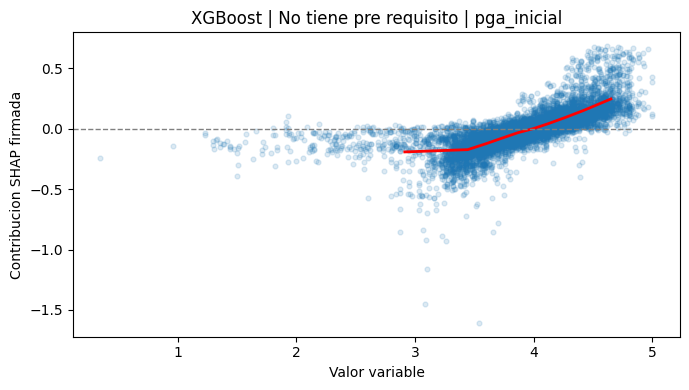

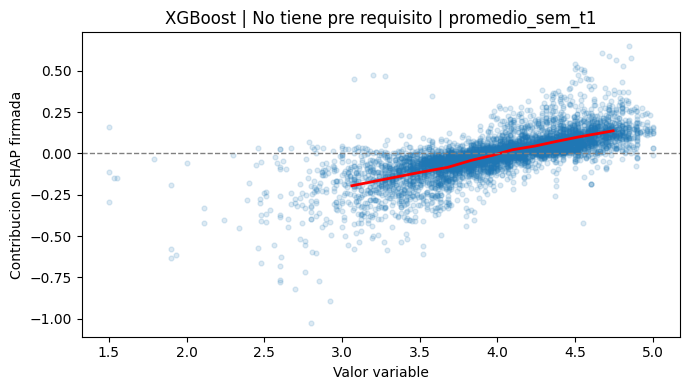

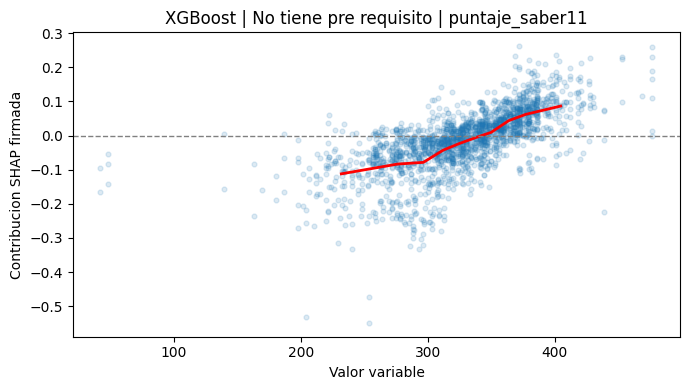

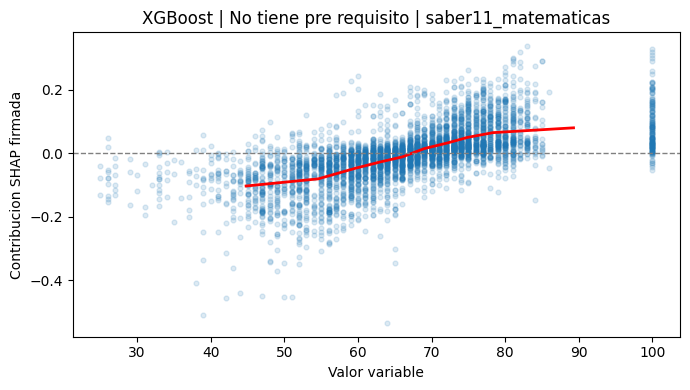

### CatBoost - Prerrequisito cumplido - Relacion variable continua vs contribucion

,model,categoria_prereq,variable,n_points,spearman_rho,pearson_r,slope,mean_signed,relation_label,abs_spearman
0,CatBoost,Prerrequisito cumplido,pga_inicial,10266,0.875179,0.819110,0.325207,-0.028689,Proporcional,0.875179
1,CatBoost,Prerrequisito cumplido,promedio_sem_t1,10284,0.860133,0.828102,0.250686,-0.014768,Proporcional,0.860133
2,CatBoost,Prerrequisito cumplido,edad_curso,9666,-0.533917,-0.526050,-0.012978,0.000867,Inversa,0.533917
3,CatBoost,Prerrequisito cumplido,asistencia_cree_t1,9792,0.411127,0.238039,0.000511,0.009623,Proporcional,0.411127
4,CatBoost,Prerrequisito cumplido,repitencia_prof_ref,5527,-0.099028,-0.004583,-0.001822,0.001692,Debil o no monotona,0.099028


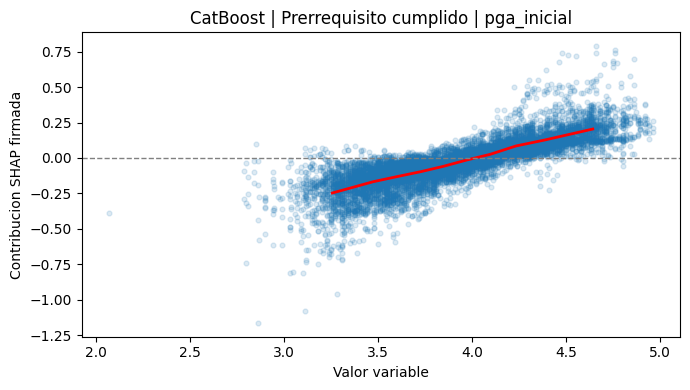

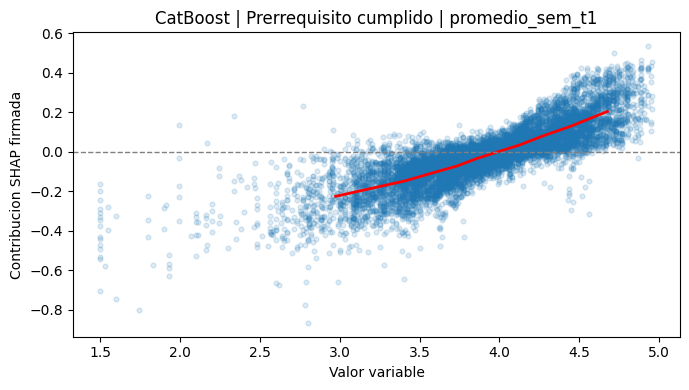

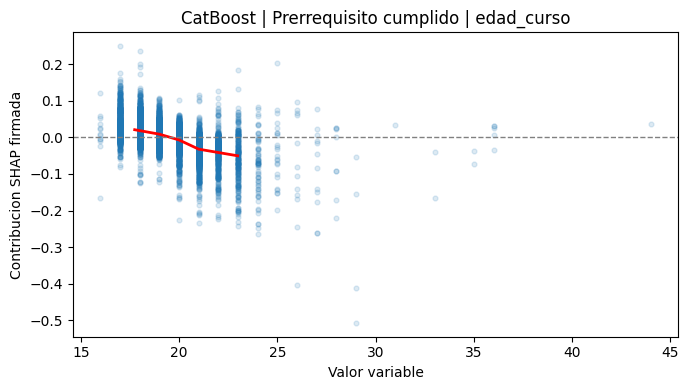

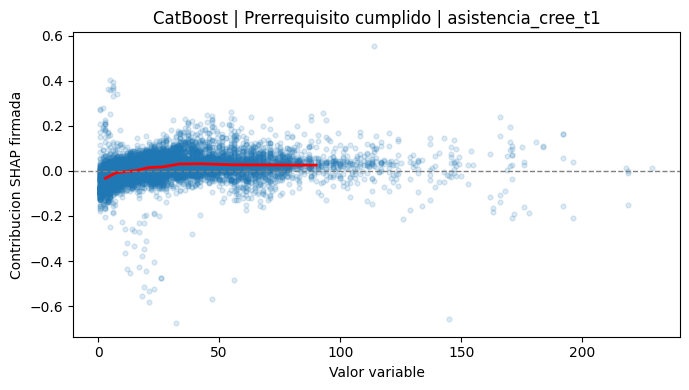

### CatBoost - No tiene pre requisito - Relacion variable continua vs contribucion

,model,categoria_prereq,variable,n_points,spearman_rho,pearson_r,slope,mean_signed,relation_label,abs_spearman
0,CatBoost,No tiene pre requisito,saber11_matematicas,1729,0.862417,0.766845,0.006018,-0.010592,Proporcional,0.862417
1,CatBoost,No tiene pre requisito,pga_inicial,7172,0.850265,0.732464,0.250760,-0.007210,Proporcional,0.850265
2,CatBoost,No tiene pre requisito,saber11_Ciencias_Naturales,1721,0.836569,0.781987,0.005542,-0.008657,Proporcional,0.836569
3,CatBoost,No tiene pre requisito,promedio_sem_t1,5315,0.833853,0.778590,0.199266,-0.006912,Proporcional,0.833853
4,CatBoost,No tiene pre requisito,puntaje_saber11,139,0.785198,0.828533,0.000703,-0.016022,Proporcional,0.785198
5,CatBoost,No tiene pre requisito,asistencia_cree_t1,6498,0.593578,0.480657,0.001057,-0.001542,Proporcional,0.593578
6,CatBoost,No tiene pre requisito,saber11_sociales,1577,0.454303,0.489624,0.001980,-0.001748,Proporcional,0.454303
7,CatBoost,No tiene pre requisito,edad_curso,7251,-0.433031,-0.393722,-0.012021,-0.001227,Inversa,0.433031
8,CatBoost,No tiene pre requisito,saber11_lectura_critica,1540,0.409953,0.328354,0.001333,-0.001842,Proporcional,0.409953
9,CatBoost,No tiene pre requisito,saber11_ingles,1602,0.236765,0.359967,0.001197,-0.000448,Proporcional,0.236765


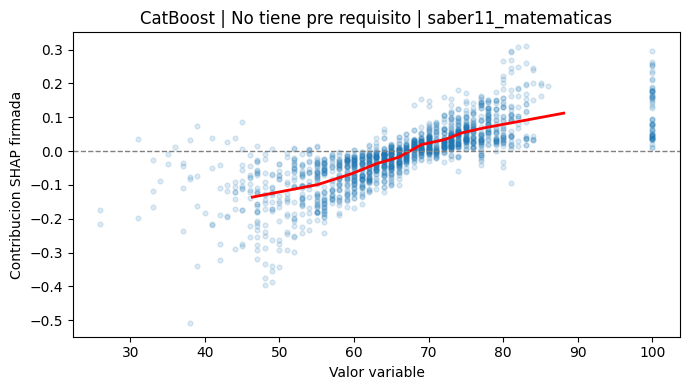

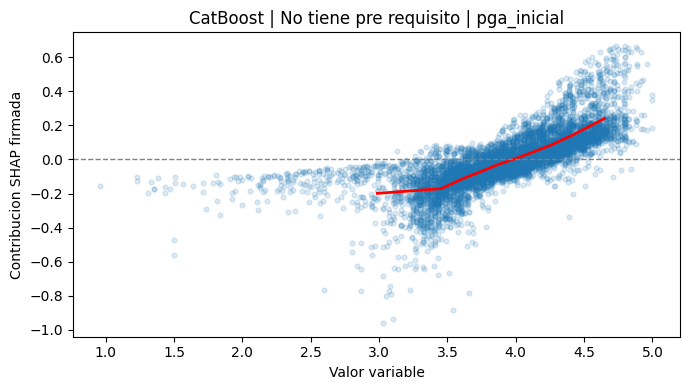

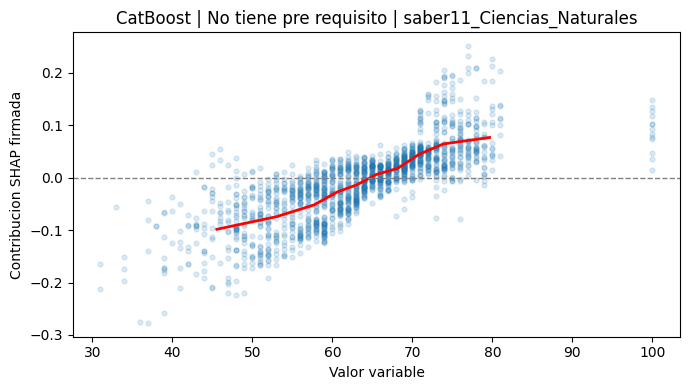

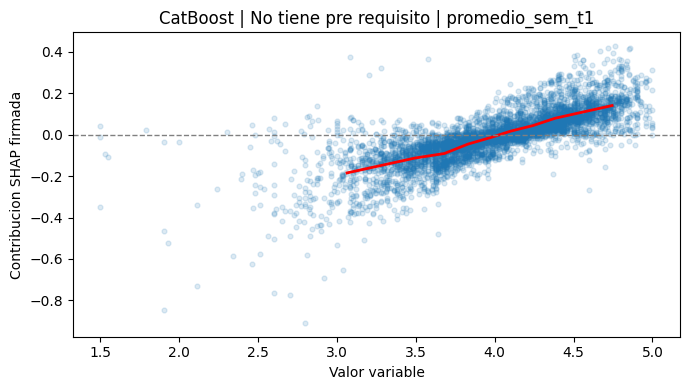

Resumen continuo generado: (32, 10)


In [80]:
def detect_continuous_feature_names(df_in, min_unique=15):
    numeric_cols = df_in.select_dtypes(include=[np.number]).columns.tolist()
    out = []
    for c in numeric_cols:
        s = pd.to_numeric(df_in[c], errors="coerce")
        n_unique = s.nunique(dropna=True)
        if n_unique >= min_unique:
            out.append(c)
    return set(out)


def classify_relation_from_rho(rho, weak_thr=0.10):
    if pd.isna(rho):
        return "Sin dato"
    if abs(rho) < weak_thr:
        return "Debil o no monotona"
    if rho > 0:
        return "Proporcional"
    return "Inversa"


def slope_simple(x, y):
    if len(x) < 2:
        return np.nan
    x_arr = np.asarray(x, dtype=float)
    y_arr = np.asarray(y, dtype=float)
    if np.allclose(np.nanstd(x_arr), 0.0):
        return np.nan
    try:
        return float(np.polyfit(x_arr, y_arr, 1)[0])
    except Exception:
        return np.nan


def build_continuous_relation_summary(df_base, registro_col, model_name, category_value, min_points=40):
    df_seg = df_base[df_base[CATEGORY_COL] == category_value].copy()
    if df_seg.empty:
        return pd.DataFrame(), pd.DataFrame()

    directional_long, _ = build_directional_long(df_seg, model_name.lower(), registro_col)
    if directional_long.empty:
        return pd.DataFrame(), pd.DataFrame()

    continuous_set = detect_continuous_feature_names(df_seg, min_unique=15)

    # Variables SHAP candidatas: deben existir en dataset, ser continuas y no ser prereq
    vars_shap = directional_long["variable"].dropna().astype(str).unique().tolist()
    candidates = [
        v for v in vars_shap
        if v in df_seg.columns
        and v in continuous_set
        and ("prereq" not in v.lower())
    ]

    rows = []
    details = []

    for var in sorted(candidates):
        sub = directional_long[directional_long["variable"] == var].copy()
        if sub.empty:
            continue

        x = pd.to_numeric(df_seg.loc[sub["row_idx"], var], errors="coerce")
        y = pd.to_numeric(sub["contrib_signed"], errors="coerce")

        pair = pd.DataFrame({"x": x.values, "y": y.values}).dropna()
        # Regla de negocio: valor 0 se considera vacio para este analisis
        pair = pair[pair["x"] != 0]
        if len(pair) < min_points:
            continue

        rho = pair["x"].corr(pair["y"], method="spearman")
        pearson = pair["x"].corr(pair["y"], method="pearson")
        slope = slope_simple(pair["x"], pair["y"])
        mean_signed = float(pair["y"].mean())

        rows.append(
            {
                "model": model_name,
                "categoria_prereq": category_value,
                "variable": var,
                "n_points": int(len(pair)),
                "spearman_rho": float(rho) if pd.notna(rho) else np.nan,
                "pearson_r": float(pearson) if pd.notna(pearson) else np.nan,
                "slope": slope,
                "mean_signed": mean_signed,
                "relation_label": classify_relation_from_rho(rho),
                "abs_spearman": abs(float(rho)) if pd.notna(rho) else np.nan,
            }
        )

        q = pair["x"].quantile([0.1, 0.5, 0.9]).values
        details.append(
            {
                "model": model_name,
                "categoria_prereq": category_value,
                "variable": var,
                "x_p10": float(q[0]),
                "x_p50": float(q[1]),
                "x_p90": float(q[2]),
                "y_mean": float(pair["y"].mean()),
            }
        )

    summary = pd.DataFrame(rows)
    detail = pd.DataFrame(details)
    if not summary.empty:
        summary = summary.sort_values(["abs_spearman", "n_points"], ascending=[False, False]).reset_index(drop=True)
    return summary, detail


def plot_relationship_examples(df_base, registro_col, model_name, category_value, summary_df, top_n=4):
    if summary_df.empty:
        print(f"{model_name} - {category_value}: sin variables continuas con puntos suficientes.")
        return

    df_seg = df_base[df_base[CATEGORY_COL] == category_value].copy()
    directional_long, _ = build_directional_long(df_seg, model_name.lower(), registro_col)

    show_vars = summary_df.head(top_n)["variable"].tolist()

    for var in show_vars:
        sub = directional_long[directional_long["variable"] == var].copy()
        x = pd.to_numeric(df_seg.loc[sub["row_idx"], var], errors="coerce")
        y = pd.to_numeric(sub["contrib_signed"], errors="coerce")
        pair = pd.DataFrame({"x": x.values, "y": y.values}).dropna()
        # Regla de negocio: valor 0 se considera vacio para visualizacion
        pair = pair[pair["x"] != 0]
        if pair.empty:
            continue

        # curva suavizada simple por bins de cuantiles
        bins = pd.qcut(pair["x"], q=min(10, pair["x"].nunique()), duplicates="drop")
        trend = pair.groupby(bins, observed=False).agg(x_mean=("x", "mean"), y_mean=("y", "mean")).dropna()

        plt.figure(figsize=(7, 4))
        plt.scatter(pair["x"], pair["y"], alpha=0.15, s=12)
        if len(trend) > 1:
            plt.plot(trend["x_mean"], trend["y_mean"], color="red", linewidth=2)
        plt.axhline(0, color="gray", linestyle="--", linewidth=1)
        plt.title(f"{model_name} | {category_value} | {var}")
        plt.xlabel("Valor variable")
        plt.ylabel("Contribucion SHAP firmada")
        plt.tight_layout()
        plt.show()


relation_parts = []
relation_detail_parts = []

for model_name, registro_col in [("XGBoost", "interpretacion_registro_xgb"), ("CatBoost", "interpretacion_registro_cat")]:
    for cat_value in CATEGORY_ORDER:
        summary_rel, detail_rel = build_continuous_relation_summary(
            df_base=df,
            registro_col=registro_col,
            model_name=model_name,
            category_value=cat_value,
            min_points=40,
        )

        display(Markdown(f"### {model_name} - {cat_value} - Relacion variable continua vs contribucion"))
        display(summary_rel.head(25))

        if not summary_rel.empty:
            relation_parts.append(summary_rel)
        if not detail_rel.empty:
            relation_detail_parts.append(detail_rel)

        plot_relationship_examples(
            df_base=df,
            registro_col=registro_col,
            model_name=model_name,
            category_value=cat_value,
            summary_df=summary_rel,
            top_n=4,
        )

continuous_relation_summary = pd.concat(relation_parts, ignore_index=True) if relation_parts else pd.DataFrame()
continuous_relation_detail = pd.concat(relation_detail_parts, ignore_index=True) if relation_detail_parts else pd.DataFrame()

print("Resumen continuo generado:", continuous_relation_summary.shape)


## 14. Puntos de corte en continuas y signos por categoria

Esta seccion identifica, por variable SHAP disponible en el dataset original:
- Continuas: aporte promedio firmado por nivel y rangos donde el aporte es positivo/negativo, incluyendo puntos de corte aproximados de negativo a positivo.
- Categoricas: categorias con aporte promedio positivo y categorias con aporte promedio negativo.

Se incluye una funcion reusable que permite analisis general y por asignatura.

In [102]:
def _resolve_registro_col(model_tag):
    model_tag = str(model_tag).strip().lower()
    if model_tag in ["xgb", "xgboost"]:
        return "interpretacion_registro_xgb", "XGBoost"
    if model_tag in ["cat", "catboost"]:
        return "interpretacion_registro_cat", "CatBoost"
    raise ValueError("model_tag debe ser xgb/xgboost o cat/catboost")


def _infer_variable_type(df_in, var, min_unique_cont=15):
    if var not in df_in.columns:
        return None

    s = df_in[var]

    # Regla principal: numericas (int/float) se tratan como continuas.
    # Esto evita que variables float con pocos niveles queden como categoricas.
    if pd.api.types.is_bool_dtype(s):
        return "categorica"

    if pd.api.types.is_numeric_dtype(s):
        return "continua"

    return "categorica"


def _cutpoints_neg_to_pos(level_df, value_col="value", contrib_col="mean_contrib"):
    out = []
    if level_df.empty:
        return out

    tmp = level_df[[value_col, contrib_col]].dropna().sort_values(value_col).reset_index(drop=True)
    if len(tmp) < 2:
        return out

    prev_x = tmp.loc[0, value_col]
    prev_y = tmp.loc[0, contrib_col]

    for i in range(1, len(tmp)):
        x = tmp.loc[i, value_col]
        y = tmp.loc[i, contrib_col]
        if (prev_y < 0) and (y > 0):
            out.append((float(prev_x + x) / 2.0, float(prev_x), float(x)))
        prev_x, prev_y = x, y

    return out


def analyze_cutpoints_and_categories(
    df_base,
    model_tag="xgb",
    categoria_prereq=None,
    asignatura=None,
    exclude_zero_continuous=True,
    min_points_var=25,
    min_unique_cont=15,
    show_tables=True,
    show_variable_tables=False,
    group_prereq_vars=True,
):
    registro_col, model_name = _resolve_registro_col(model_tag)

    work = df_base.copy()
    if categoria_prereq is not None:
        work = work[work[CATEGORY_COL] == categoria_prereq].copy()
    if asignatura is not None:
        work = work[work["Descripcion_Materia"] == asignatura].copy()

    if work.empty:
        print("Sin datos luego de aplicar filtros.")
        return {
            "continuous_summary": pd.DataFrame(),
            "categorical_summary": pd.DataFrame(),
            "continuous_tables": {},
            "categorical_tables": {},
        }

    directional_long, parse_report = build_directional_long(work, model_tag, registro_col)
    print("Reporte parsing direccional:", {k: v for k, v in parse_report.items() if k != "not_parsed_examples"})

    if directional_long.empty:
        print("No hay datos direccionales parseados para analizar.")
        return {
            "continuous_summary": pd.DataFrame(),
            "categorical_summary": pd.DataFrame(),
            "continuous_tables": {},
            "categorical_tables": {},
        }

    # Control de prerequisitos: agrupados como en celda 8 (Prereq_Nota/Intentos/Otros)
    # o especificos por variable cuando se requiera (por ejemplo, por asignatura).
    directional_long = directional_long.copy()
    if group_prereq_vars:
        directional_long["variable_eff"] = directional_long["variable"].astype(str).apply(group_prereq)
    else:
        directional_long["variable_eff"] = directional_long["variable"].astype(str)

    shap_vars = sorted(directional_long["variable_eff"].dropna().astype(str).unique())

    continuous_tables = {}
    categorical_tables = {}
    continuous_rows = []
    categorical_rows = []

    def _append_continuous_from_pair(var_name, pair):
        if pair.empty:
            return

        level = (
            pair.groupby("x", as_index=False)
            .agg(n=("y", "size"), mean_contrib=("y", "mean"), median_contrib=("y", "median"))
            .sort_values("x")
            .reset_index(drop=True)
        )
        if level.empty:
            return

        pos_vals = level.loc[level["mean_contrib"] > 0, "x"]
        neg_vals = level.loc[level["mean_contrib"] < 0, "x"]
        cuts = _cutpoints_neg_to_pos(level, value_col="x", contrib_col="mean_contrib")
        cut_text = "; ".join([f"{c[0]:.4f} (entre {c[1]:.4f} y {c[2]:.4f})" for c in cuts]) if cuts else "No detectado"

        continuous_rows.append(
            {
                "model": model_name,
                "categoria_prereq": categoria_prereq if categoria_prereq is not None else "Todas",
                "asignatura": asignatura if asignatura is not None else "Todas",
                "variable": var_name,
                "n_points": int(len(pair)),
                "n_levels": int(level["x"].nunique()),
                "min_val_positive": float(pos_vals.min()) if not pos_vals.empty else np.nan,
                "max_val_positive": float(pos_vals.max()) if not pos_vals.empty else np.nan,
                "min_val_negative": float(neg_vals.min()) if not neg_vals.empty else np.nan,
                "max_val_negative": float(neg_vals.max()) if not neg_vals.empty else np.nan,
                "cutpoints_neg_to_pos": cut_text,
                "mean_signed_global": float(pair["y"].mean()),
            }
        )

        tbl = level.rename(columns={"x": "value"}).copy()
        tbl["sign_label"] = np.where(tbl["mean_contrib"] > 0, "Positivo", np.where(tbl["mean_contrib"] < 0, "Negativo", "Neutro"))
        continuous_tables[var_name] = tbl

    def _build_prereq_acc_pair(suffix):
        # x: promedio por fila de columnas Prereq*_<suffix> (excluyendo 0 y NaN)
        cols = [c for c in work.columns if str(c).startswith("Prereq") and str(c).endswith(suffix)]
        if not cols:
            return pd.DataFrame()

        x_df = work[cols].apply(pd.to_numeric, errors="coerce")
        x_df = x_df.replace(0, np.nan)
        x_mean = x_df.mean(axis=1, skipna=True)

        # y: suma por fila de contribuciones SHAP de variables Prereq*_<suffix>
        mask = directional_long["variable"].astype(str).str.startswith("Prereq") & directional_long["variable"].astype(str).str.endswith(suffix)
        y_sum = (
            directional_long.loc[mask, ["row_idx", "contrib_signed"]]
            .assign(contrib_signed=lambda d: pd.to_numeric(d["contrib_signed"], errors="coerce"))
            .dropna(subset=["contrib_signed"])
            .groupby("row_idx")["contrib_signed"].sum()
        )
        if y_sum.empty:
            return pd.DataFrame()

        pair = pd.DataFrame({"x": x_mean, "y": y_sum}).dropna()
        pair["x"] = pd.to_numeric(pair["x"], errors="coerce")
        pair["y"] = pd.to_numeric(pair["y"], errors="coerce")
        pair = pair.dropna()
        if exclude_zero_continuous:
            pair = pair[pair["x"] != 0]
        return pair

    # Variables continuas agregadas de prerequisitos (vista numerica)
    pair_prereq_nota = _build_prereq_acc_pair("_Nota")
    if len(pair_prereq_nota) >= min_points_var:
        _append_continuous_from_pair("Prereq_Nota_Acumulada", pair_prereq_nota)

    pair_prereq_intentos = _build_prereq_acc_pair("_Intentos")
    if len(pair_prereq_intentos) >= min_points_var:
        _append_continuous_from_pair("Prereq_Intentos_Acumulada", pair_prereq_intentos)

    for var_eff in shap_vars:
        sub = directional_long[directional_long["variable_eff"] == var_eff].copy()
        if sub.empty:
            continue

        # Variables no prereq: deben existir en dataset original
        if var_eff not in work.columns:
            continue

        var_type = _infer_variable_type(work, var_eff, min_unique_cont=min_unique_cont)
        if var_type is None:
            continue

        x = work.loc[sub["row_idx"], var_eff]
        y = pd.to_numeric(sub["contrib_signed"], errors="coerce")

        pair = pd.DataFrame({"x": x.values, "y": y.values}).dropna()
        if len(pair) < min_points_var:
            continue

        if var_type == "continua":
            pair["x"] = pd.to_numeric(pair["x"], errors="coerce")
            pair = pair.dropna()
            if exclude_zero_continuous:
                pair = pair[pair["x"] != 0]
            if len(pair) < min_points_var:
                continue

            _append_continuous_from_pair(var_eff, pair)

        else:
            pair["x"] = pair["x"].astype(str).str.strip()
            pair = pair[pair["x"] != ""]
            if len(pair) < min_points_var:
                continue

            level = (
                pair.groupby("x", as_index=False)
                .agg(n=("y", "size"), mean_contrib=("y", "mean"), median_contrib=("y", "median"))
                .sort_values(["mean_contrib", "n"], ascending=[False, False])
                .reset_index(drop=True)
            )

            pos_cats = level.loc[level["mean_contrib"] > 0, "x"].tolist()
            neg_cats = level.loc[level["mean_contrib"] < 0, "x"].tolist()

            categorical_rows.append(
                {
                    "model": model_name,
                    "categoria_prereq": categoria_prereq if categoria_prereq is not None else "Todas",
                    "asignatura": asignatura if asignatura is not None else "Todas",
                    "variable": var_eff,
                    "n_points": int(len(pair)),
                    "n_categories": int(level["x"].nunique()),
                    "categorias_positivas": " | ".join(pos_cats[:15]) if pos_cats else "",
                    "categorias_negativas": " | ".join(neg_cats[:15]) if neg_cats else "",
                    "mean_signed_global": float(pair["y"].mean()),
                }
            )

            tbl = level.rename(columns={"x": "category"}).copy()
            tbl["sign_label"] = np.where(tbl["mean_contrib"] > 0, "Positivo", np.where(tbl["mean_contrib"] < 0, "Negativo", "Neutro"))
            categorical_tables[var_eff] = tbl

    continuous_summary = pd.DataFrame(continuous_rows).sort_values("variable") if continuous_rows else pd.DataFrame()
    categorical_summary = pd.DataFrame(categorical_rows).sort_values("variable") if categorical_rows else pd.DataFrame()

    if show_tables:
        display(Markdown(f"### {model_name} - Resumen continuas"))
        display(continuous_summary)
        display(Markdown(f"### {model_name} - Resumen categoricas"))
        display(categorical_summary)

    if show_variable_tables:
        for var, t in continuous_tables.items():
            display(Markdown(f"#### Continua: {var}"))
            display(t)
        for var, t in categorical_tables.items():
            display(Markdown(f"#### Categorica: {var}"))
            display(t)

    return {
        "continuous_summary": continuous_summary,
        "categorical_summary": categorical_summary,
        "continuous_tables": continuous_tables,
        "categorical_tables": categorical_tables,
    }


# 1) Resultados generales
section14_general = analyze_cutpoints_and_categories(
    df_base=df,
    model_tag="xgb",
    categoria_prereq=None,
    asignatura=None,
    exclude_zero_continuous=True,
    min_points_var=25,
    min_unique_cont=15,
    show_tables=True,
    show_variable_tables=False,
    group_prereq_vars=True,
)

# 2) Resultados: solo Prerrequisito cumplido
section14_con_prereq = analyze_cutpoints_and_categories(
    df_base=df,
    model_tag="xgb",
    categoria_prereq=CAT_HAS,
    asignatura=None,
    exclude_zero_continuous=True,
    min_points_var=25,
    min_unique_cont=15,
    show_tables=True,
    show_variable_tables=False,
    group_prereq_vars=True,
)

# 3) Resultados: solo No tiene pre requisito
section14_sin_prereq = analyze_cutpoints_and_categories(
    df_base=df,
    model_tag="xgb",
    categoria_prereq=CAT_NO,
    asignatura=None,
    exclude_zero_continuous=True,
    min_points_var=25,
    min_unique_cont=15,
    show_tables=True,
    show_variable_tables=False,
    group_prereq_vars=True,
)

# 4) Resultados: una asignatura aleatoria
random_subject = None
if "Descripcion_Materia" in df.columns and df["Descripcion_Materia"].notna().any():
    random_subject = df["Descripcion_Materia"].dropna().sample(1, random_state=42).iloc[0]
    random_subject = 'FÍSICA MECANICA'
    subject_rows = df[df["Descripcion_Materia"] == random_subject].copy()
    subject_has_prereq = bool(subject_rows[CATEGORY_COL].eq(CAT_HAS).any())

    display(Markdown(f"### Analisis por asignatura al azar: {random_subject}"))
    print("Categoria prerequisito de la asignatura:", CAT_HAS if subject_has_prereq else CAT_NO)

    # Si tiene prerequisitos, usar variables prereq especificas (no agrupadas)
    section14_random_subject = analyze_cutpoints_and_categories(
        df_base=df,
        model_tag="xgb",
        categoria_prereq=None,
        asignatura=random_subject,
        exclude_zero_continuous=True,
        min_points_var=10,
        min_unique_cont=5,
        show_tables=True,
        show_variable_tables=False,
        group_prereq_vars=(False if subject_has_prereq else True),
    )
else:
    section14_random_subject = {
        "continuous_summary": pd.DataFrame(),
        "categorical_summary": pd.DataFrame(),
        "continuous_tables": {},
        "categorical_tables": {},
    }


Reporte parsing direccional: {'total_rows': 20700, 'parsed_rows': 20700, 'not_parsed_rows': 0}


### XGBoost - Resumen continuas

,model,categoria_prereq,asignatura,variable,n_points,n_levels,min_val_positive,max_val_positive,min_val_negative,max_val_negative,cutpoints_neg_to_pos,mean_signed_global
1,XGBoost,Todas,Todas,Prereq_Intentos_Acumulada,8973,35,1.000000,1.384615,1.071429,6.000,1.0742 (entre 1.0714 y 1.0769); 1.0931 (entre ...,-0.002066
0,XGBoost,Todas,Todas,Prereq_Nota_Acumulada,10071,480,3.436364,5.000000,2.800000,4.475,3.4360 (entre 3.4357 y 3.4364); 3.6000 (entre ...,-0.029064
2,XGBoost,Todas,Todas,asistencia_cree_t1,16679,181,19.000000,289.000000,1.000000,233.000,18.5000 (entre 18.0000 y 19.0000); 106.5000 (e...,0.000485
3,XGBoost,Todas,Todas,años_saber11_vs_clase,2474,12,1.000000,12.000000,2.000000,11.000,8.5000 (entre 8.0000 y 9.0000); 11.5000 (entre...,-0.003068
4,XGBoost,Todas,Todas,edad_curso,19656,21,17.000000,19.000000,16.000000,44.000,16.5000 (entre 16.0000 y 17.0000),-0.000829
5,XGBoost,Todas,Todas,num_intentos_asignatura,16888,9,1.000000,1.000000,2.000000,9.000,No detectado,-0.002438
6,XGBoost,Todas,Todas,num_semestres_profesor_asignatura,19227,14,1.000000,2.000000,3.000000,14.000,No detectado,-0.013864
7,XGBoost,Todas,Todas,pga_inicial,17620,608,1.802000,5.000000,0.348000,4.000,1.7920 (entre 1.7820 y 1.8020); 1.8730 (entre ...,-0.025151
8,XGBoost,Todas,Todas,promedio_sem_t1,15636,275,4.000000,5.000000,1.500000,3.990,3.9950 (entre 3.9900 y 4.0000),-0.009159
9,XGBoost,Todas,Todas,puntaje_saber11,1947,204,335.000000,477.000000,42.000000,439.000,334.5000 (entre 334.0000 y 335.0000); 338.5000...,-0.015071


### XGBoost - Resumen categoricas

,model,categoria_prereq,asignatura,variable,n_points,n_categories,categorias_positivas,categorias_negativas,mean_signed_global
0,XGBoost,Todas,Todas,Tipo_calendario,8011,3,Calendario B | I,Calendario A,-0.000651
1,XGBoost,Todas,Todas,Tipo_colegio,8987,4,Institución Oficial | I | Colegio Bilingüe,Institución Privada,-0.000030
2,XGBoost,Todas,Todas,estrato,19597,6,3 | 2,4 | 5 | 1 | 6,-0.001578
3,XGBoost,Todas,Todas,procedencia_categoria,19299,5,5 Otro pais | 1 Area Metro B/quilla | 3 Otros ...,2 Otro Muni Atlantico | 4 Otra region-Dpto de ...,0.001274
4,XGBoost,Todas,Todas,profesor_codigo,20316,436,3652 | 978 | 2531 | 5133 | 3170 | 3370 | 2112 ...,3255 | 5615 | 2438 | 2973 | 3029 | 2821 | 5943...,-0.016058
5,XGBoost,Todas,Todas,programa,16407,30,Psicología - BARRANQUILLA | Odontología - BAR...,Geología - BARRANQUILLA | Administración de Em...,0.018753
6,XGBoost,Todas,Todas,sexo,19807,3,F,N | M,-0.000637


...

Categoria prerequisito de la asignatura: Prerrequisito cumplido
Reporte parsing direccional: {'total_rows': 303, 'parsed_rows': 303, 'not_parsed_rows': 0}


### XGBoost - Resumen continuas

,model,categoria_prereq,asignatura,variable,n_points,n_levels,min_val_positive,max_val_positive,min_val_negative,max_val_negative,cutpoints_neg_to_pos,mean_signed_global
1,XGBoost,Todas,FÍSICA MECANICA,Prereq_Intentos_Acumulada,300,3,1.00,1.00,2.00,3.00,No detectado,-0.005717
0,XGBoost,Todas,FÍSICA MECANICA,Prereq_Nota_Acumulada,302,21,3.50,5.00,3.00,4.10,3.4500 (entre 3.4000 y 3.5000); 4.1500 (entre ...,-0.017228
2,XGBoost,Todas,FÍSICA MECANICA,Prereq_calculo_i_Intentos,300,3,1.00,1.00,2.00,3.00,No detectado,-0.005717
3,XGBoost,Todas,FÍSICA MECANICA,Prereq_calculo_i_Nota,302,21,3.50,5.00,3.00,4.10,3.4500 (entre 3.4000 y 3.5000); 4.1500 (entre ...,-0.017228
4,XGBoost,Todas,FÍSICA MECANICA,asistencia_cree_t1,290,47,5.00,56.00,1.00,29.00,4.5000 (entre 4.0000 y 5.0000); 9.5000 (entre ...,0.003400
5,XGBoost,Todas,FÍSICA MECANICA,edad_curso,294,8,16.00,18.00,19.00,23.00,No detectado,0.004340
6,XGBoost,Todas,FÍSICA MECANICA,num_intentos_asignatura,281,6,1.00,1.00,2.00,6.00,No detectado,-0.000502
7,XGBoost,Todas,FÍSICA MECANICA,num_semestres_profesor_asignatura,300,5,4.00,4.00,1.00,13.00,2.5000 (entre 1.0000 y 4.0000),-0.016467
8,XGBoost,Todas,FÍSICA MECANICA,pga_inicial,303,140,3.97,4.96,2.79,4.20,3.9600 (entre 3.9500 y 3.9700); 3.9950 (entre ...,0.003571
9,XGBoost,Todas,FÍSICA MECANICA,promedio_sem_t1,303,146,4.03,4.96,2.56,4.08,4.0150 (entre 4.0000 y 4.0300); 4.0850 (entre ...,0.063611


### XGBoost - Resumen categoricas

,model,categoria_prereq,asignatura,variable,n_points,n_categories,categorias_positivas,categorias_negativas,mean_signed_global
0,XGBoost,Todas,FÍSICA MECANICA,estrato,299,6,1 | 5 | 4 | 3 | 6,2,-0.000107
1,XGBoost,Todas,FÍSICA MECANICA,procedencia_categoria,294,5,5 Otro pais | 3 Otros Municipios del caribe,1 Area Metro B/quilla | 4 Otra region-Dpto de ...,-0.000602
2,XGBoost,Todas,FÍSICA MECANICA,profesor_codigo,303,10,3584 | 2891,1614 | 6092 | 3665 | 5504 | 6093 | 4627 | 3588...,-0.090350
3,XGBoost,Todas,FÍSICA MECANICA,programa,303,9,Matemáticas - BARRANQUILLA | Ingeniería de Sis...,Ingeniería Eléctrica - BARRANQUILLA | Ingenie...,0.032729
4,XGBoost,Todas,FÍSICA MECANICA,sexo,296,2,M,F,-0.000861


## 15. Analisis de punto de corte asistencia_cree_t1

In [103]:
def cutpoint_summary_by_course_for_variable(
    df_base,
    variable_name="asistencia_cree_t1",
    model_tag="xgb",
    exclude_zero_continuous=True,
    min_points_var=10,
):
    registro_col, model_name = _resolve_registro_col(model_tag)

    if variable_name not in df_base.columns:
        raise ValueError(f"La variable {variable_name} no existe en el dataset base.")

    directional_long, parse_report = build_directional_long(df_base, model_tag, registro_col)
    print("Reporte parsing direccional:", {k: v for k, v in parse_report.items() if k != "not_parsed_examples"})

    sub = directional_long[directional_long["variable"] == variable_name].copy()
    if sub.empty:
        return pd.DataFrame()

    x = pd.to_numeric(df_base.loc[sub["row_idx"], variable_name], errors="coerce")
    y = pd.to_numeric(sub["contrib_signed"], errors="coerce")
    course = df_base.loc[sub["row_idx"], "Descripcion_Materia"].astype(str)

    pair = pd.DataFrame({"asignatura": course.values, "x": x.values, "y": y.values}).dropna()
    if exclude_zero_continuous:
        pair = pair[pair["x"] != 0]

    out_rows = []

    for asignatura, g in pair.groupby("asignatura"):
        if len(g) < min_points_var:
            continue

        level = (
            g.groupby("x", as_index=False)
            .agg(n=("y", "size"), mean_contrib=("y", "mean"))
            .sort_values("x")
            .reset_index(drop=True)
        )

        pos_vals = level.loc[level["mean_contrib"] > 0, "x"]
        neg_vals = level.loc[level["mean_contrib"] < 0, "x"]

        cuts = _cutpoints_neg_to_pos(level, value_col="x", contrib_col="mean_contrib")
        cut_text = "; ".join([f"{c[0]:.4f} (entre {c[1]:.4f} y {c[2]:.4f})" for c in cuts]) if cuts else "No detectado"

        out_rows.append(
            {
                "model": model_name,
                "asignatura": asignatura,
                "variable": variable_name,
                "n_points": int(len(g)),
                "min_val_positive": float(pos_vals.min()) if not pos_vals.empty else np.nan,
                "max_val_positive": float(pos_vals.max()) if not pos_vals.empty else np.nan,
                "min_val_negative": float(neg_vals.min()) if not neg_vals.empty else np.nan,
                "max_val_negative": float(neg_vals.max()) if not neg_vals.empty else np.nan,
                "cutpoints_neg_to_pos": cut_text,
                "mean_signed_global": float(g["y"].mean()),
            }
        )

    out = pd.DataFrame(out_rows)
    if not out.empty:
        out = out.sort_values(["mean_signed_global", "n_points"], ascending=[False, False]).reset_index(drop=True)
    return out


section15_asistencia_cree_t1 = cutpoint_summary_by_course_for_variable(
    df_base=df,
    variable_name="asistencia_cree_t1",
    model_tag="xgb",
    exclude_zero_continuous=True,
    min_points_var=10,
)

display(section15_asistencia_cree_t1.head(10))


Reporte parsing direccional: {'total_rows': 20700, 'parsed_rows': 20700, 'not_parsed_rows': 0}


,model,asignatura,variable,n_points,min_val_positive,max_val_positive,min_val_negative,max_val_negative,cutpoints_neg_to_pos,mean_signed_global
0,XGBoost,MECANICA DE FLUIDOS,asistencia_cree_t1,19,24.0,171.0,16.0,16.0,20.0000 (entre 16.0000 y 24.0000),0.055000
1,XGBoost,PLANEACION FINANCIERA,asistencia_cree_t1,164,14.0,71.0,2.0,13.0,13.5000 (entre 13.0000 y 14.0000),0.039549
2,XGBoost,MATEMATICAS DISCRETAS,asistencia_cree_t1,146,12.0,92.0,2.0,38.0,11.5000 (entre 11.0000 y 12.0000); 18.5000 (en...,0.036589
3,XGBoost,ADMINISTRATIVO I,asistencia_cree_t1,57,2.0,65.0,3.0,27.0,6.5000 (entre 5.0000 y 8.0000); 22.0000 (entre...,0.035404
4,XGBoost,ESTÁTICA,asistencia_cree_t1,98,17.0,124.0,6.0,50.0,16.5000 (entre 16.0000 y 17.0000); 50.5000 (en...,0.029510
5,XGBoost,HRIA. DE BARRANQUILLA,asistencia_cree_t1,80,5.0,204.0,1.0,14.0,4.5000 (entre 4.0000 y 5.0000); 12.5000 (entre...,0.026700
6,XGBoost,EXIGENCIA DE FRANCES V,asistencia_cree_t1,42,10.0,113.0,4.0,68.0,8.0000 (entre 6.0000 y 10.0000); 15.5000 (entr...,0.023548
7,XGBoost,ESTADISTICA II (AD),asistencia_cree_t1,141,7.0,93.0,2.0,29.0,6.5000 (entre 6.0000 y 7.0000); 15.0000 (entre...,0.023050
8,XGBoost,ESTRUCTURA DE DATOS I-IS,asistencia_cree_t1,100,11.0,75.0,2.0,39.0,10.5000 (entre 10.0000 y 11.0000); 13.5000 (en...,0.022910
9,XGBoost,ESTRUCTURAS DISCRETAS,asistencia_cree_t1,79,12.0,170.0,7.0,219.0,11.5000 (entre 11.0000 y 12.0000); 18.0000 (en...,0.022456
